# Measuring blur

We want to see how objects blur at different depth (how far they are in the scene).  
Currently I'm only concerned with street view images (which follow projective geometry quite well)  

In [97]:
from pathlib import Path
import matplotlib.pyplot as plt
import itertools
import functools
import cv2
import numpy as np

In [98]:
DS = Path("../../datasets")
BLUR_DS = DS / "blur"
TPAPER = BLUR_DS / "toilet-paper"

In [99]:
papers = list(TPAPER.glob("*.jpg"))
orig = papers[7]
wash_1_1 = papers[6]
wash_1_2 = papers[4]
wash_2 = papers[5]
wash_3 = papers[0]
wash_4 = papers[1]

gate_1 = papers[3]
gate_2 = papers[2]
gate_3 = papers[8]

In [100]:
import math


def show_rx2(crops, figsize=None, ncols=2):
    rows = math.ceil(len(crops) / ncols)
    if figsize is None:
        figsize = (10 * rows, 10 * rows)
        print("figsize", figsize)
    _, axs = plt.subplots(rows, ncols, figsize=figsize)
    axs = axs.flatten()
    for i, c in enumerate(crops):
        axs[i].imshow(c)
    plt.tight_layout()
    plt.show()


def sobel_edge_detection(img_rgb):
    # Load the image in grayscale
    # Compute the 1st order Sobel derivative in X-direction
    # ddepth is set to cv2.CV_64F to handle negative gradient values
    img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)

    # Compute the 1st order Sobel derivative in Y-direction
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    # Compute the magnitude of the gradient (optional, for combined edge strength)
    # The gradient magnitude is calculated as sqrt(sobelx^2 + sobely^2)
    grad_magnitude = np.sqrt(sobelx**2 + sobely**2)

    # Convert results back to 8-bit image for display
    # Taking absolute values is important before converting to uint8
    return (
        cv2.convertScaleAbs(sobelx),
        cv2.convertScaleAbs(sobely),
        cv2.convertScaleAbs(grad_magnitude),
    )

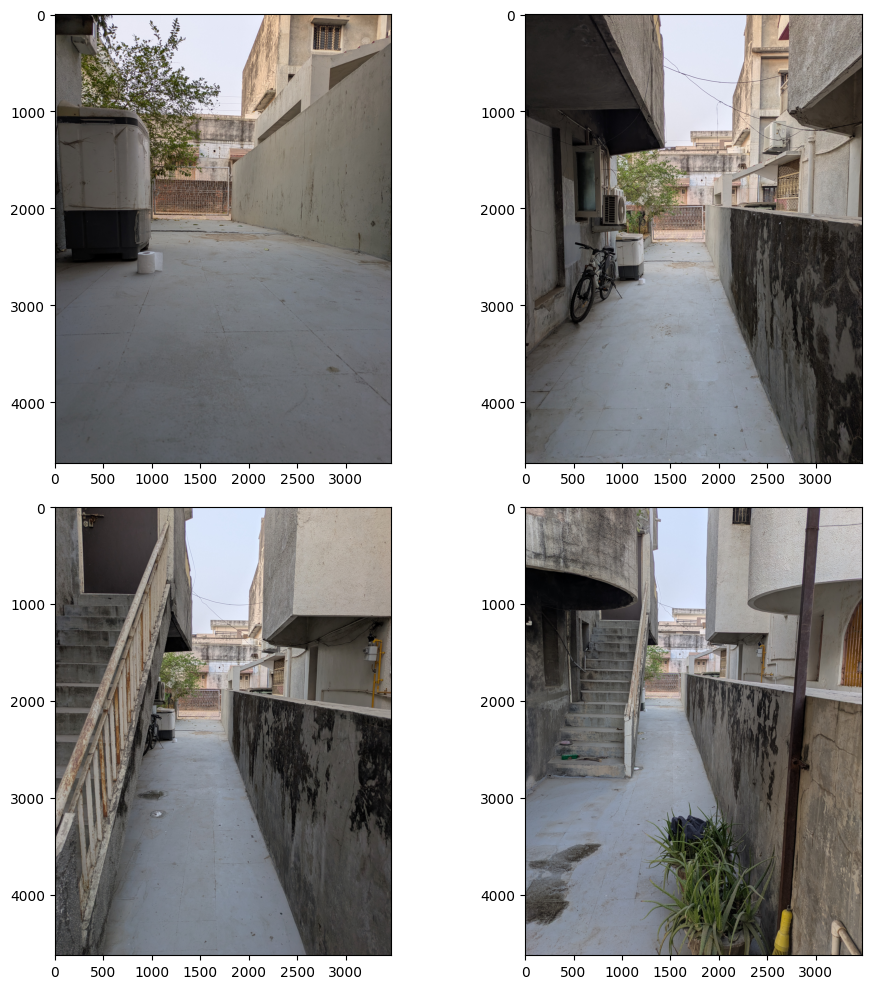

In [101]:
figs = [
    plt.imread(w)
    for w in [
        wash_1_2,
        wash_2,
        wash_3,
        wash_4,
    ]
]

show_rx2(figs, (10, 10))

# Wash: 2 -> 1

Try transforming the photo in 2 to photo 1

figsize (10, 10)


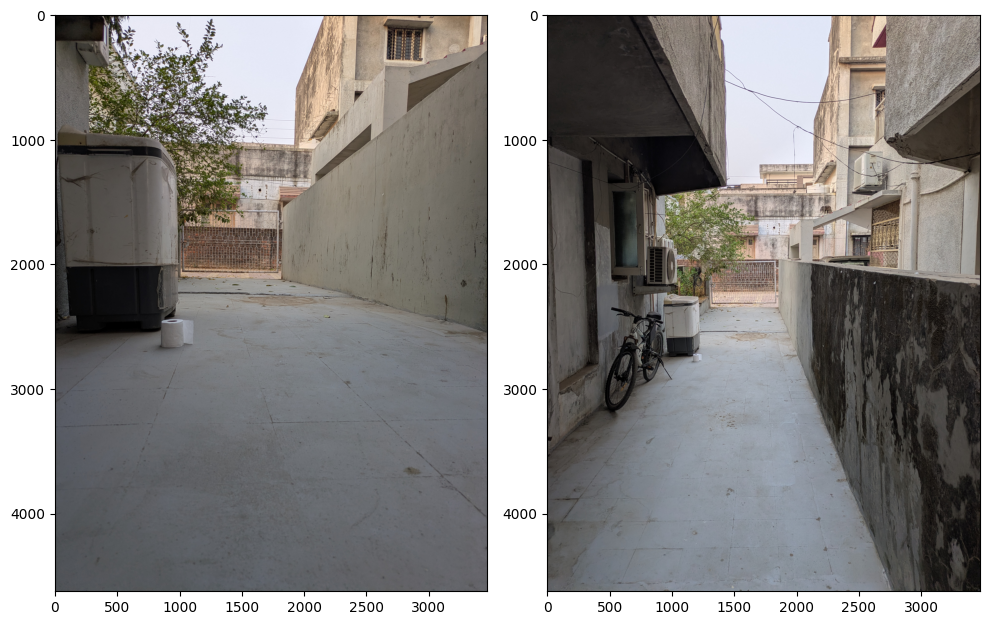

In [102]:
show_rx2(figs[:2])

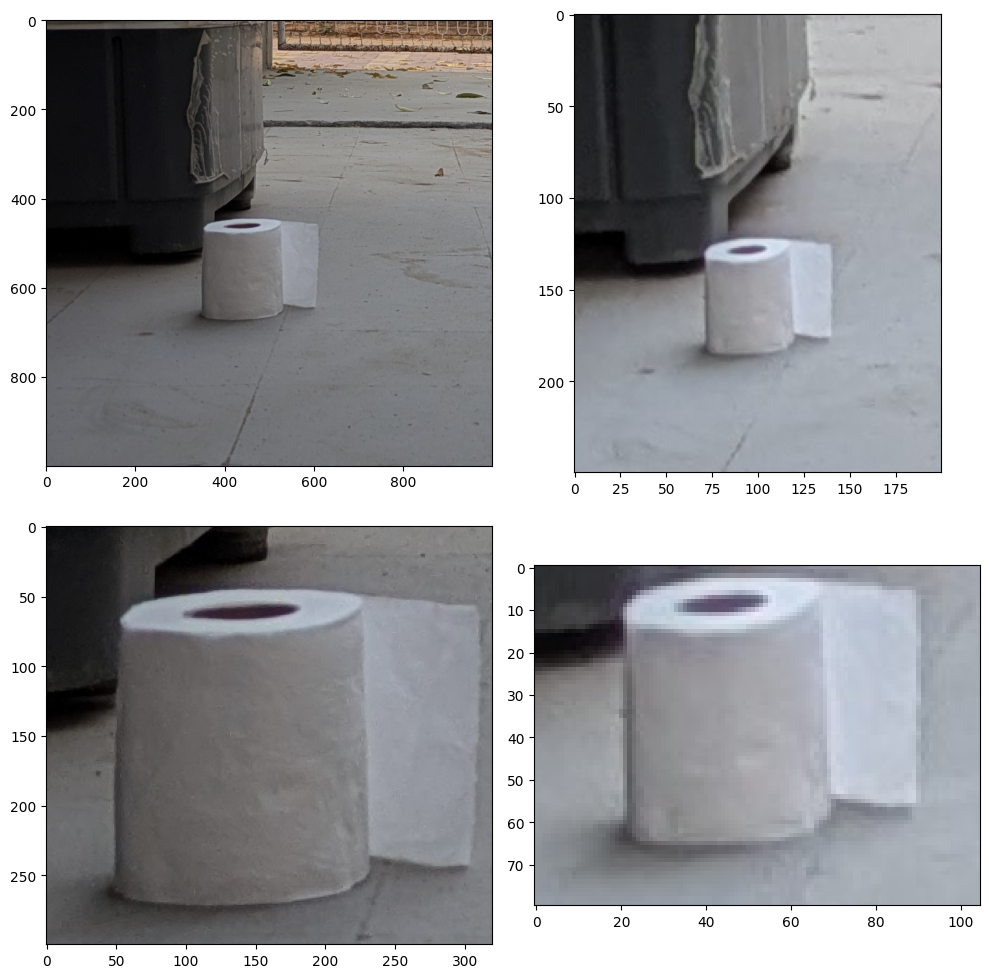

In [103]:
w2_roll = figs[1][2600:2850, 1100:1300]
w12_full_roll = figs[0][2000:3000, 500:1500]
w12_closeup = w12_full_roll[400:700, 300:620]
w2_closeup = w2_roll[120:200, 50:155]
show_rx2([w12_full_roll, w2_roll, w12_closeup, w2_closeup], figsize=(10, 10))

- If we look at the close-ups of the toilet paper, the first roll is about three to four times larger than the other roll. 
  - This is in terms of the pixels the roll takes.
- Let's resize the last closeup to the other closeups size.


In [104]:
def _resize(img, w, interpolation):
    new_width = w
    aspect_ratio = new_width / img.shape[1]
    new_height = int(img.shape[0] * aspect_ratio)
    return cv2.resize(img, (new_width, new_height), interpolation=interpolation)


def _res(img, interp):
    return _resize(img, w2_closeup.shape[1], interp)


resized_w12_nearest = _res(w12_closeup, cv2.INTER_NEAREST)
resized_w12_linear = _res(w12_closeup, cv2.INTER_LINEAR)
resized_w12_cubic = _res(w12_closeup, cv2.INTER_CUBIC)
resized_w12_area = _res(w12_closeup, cv2.INTER_AREA)
resized_w12_lancoz = _res(w12_closeup, cv2.INTER_LANCZOS4)

In [105]:
def flt(it):
    return list(itertools.chain.from_iterable(it))

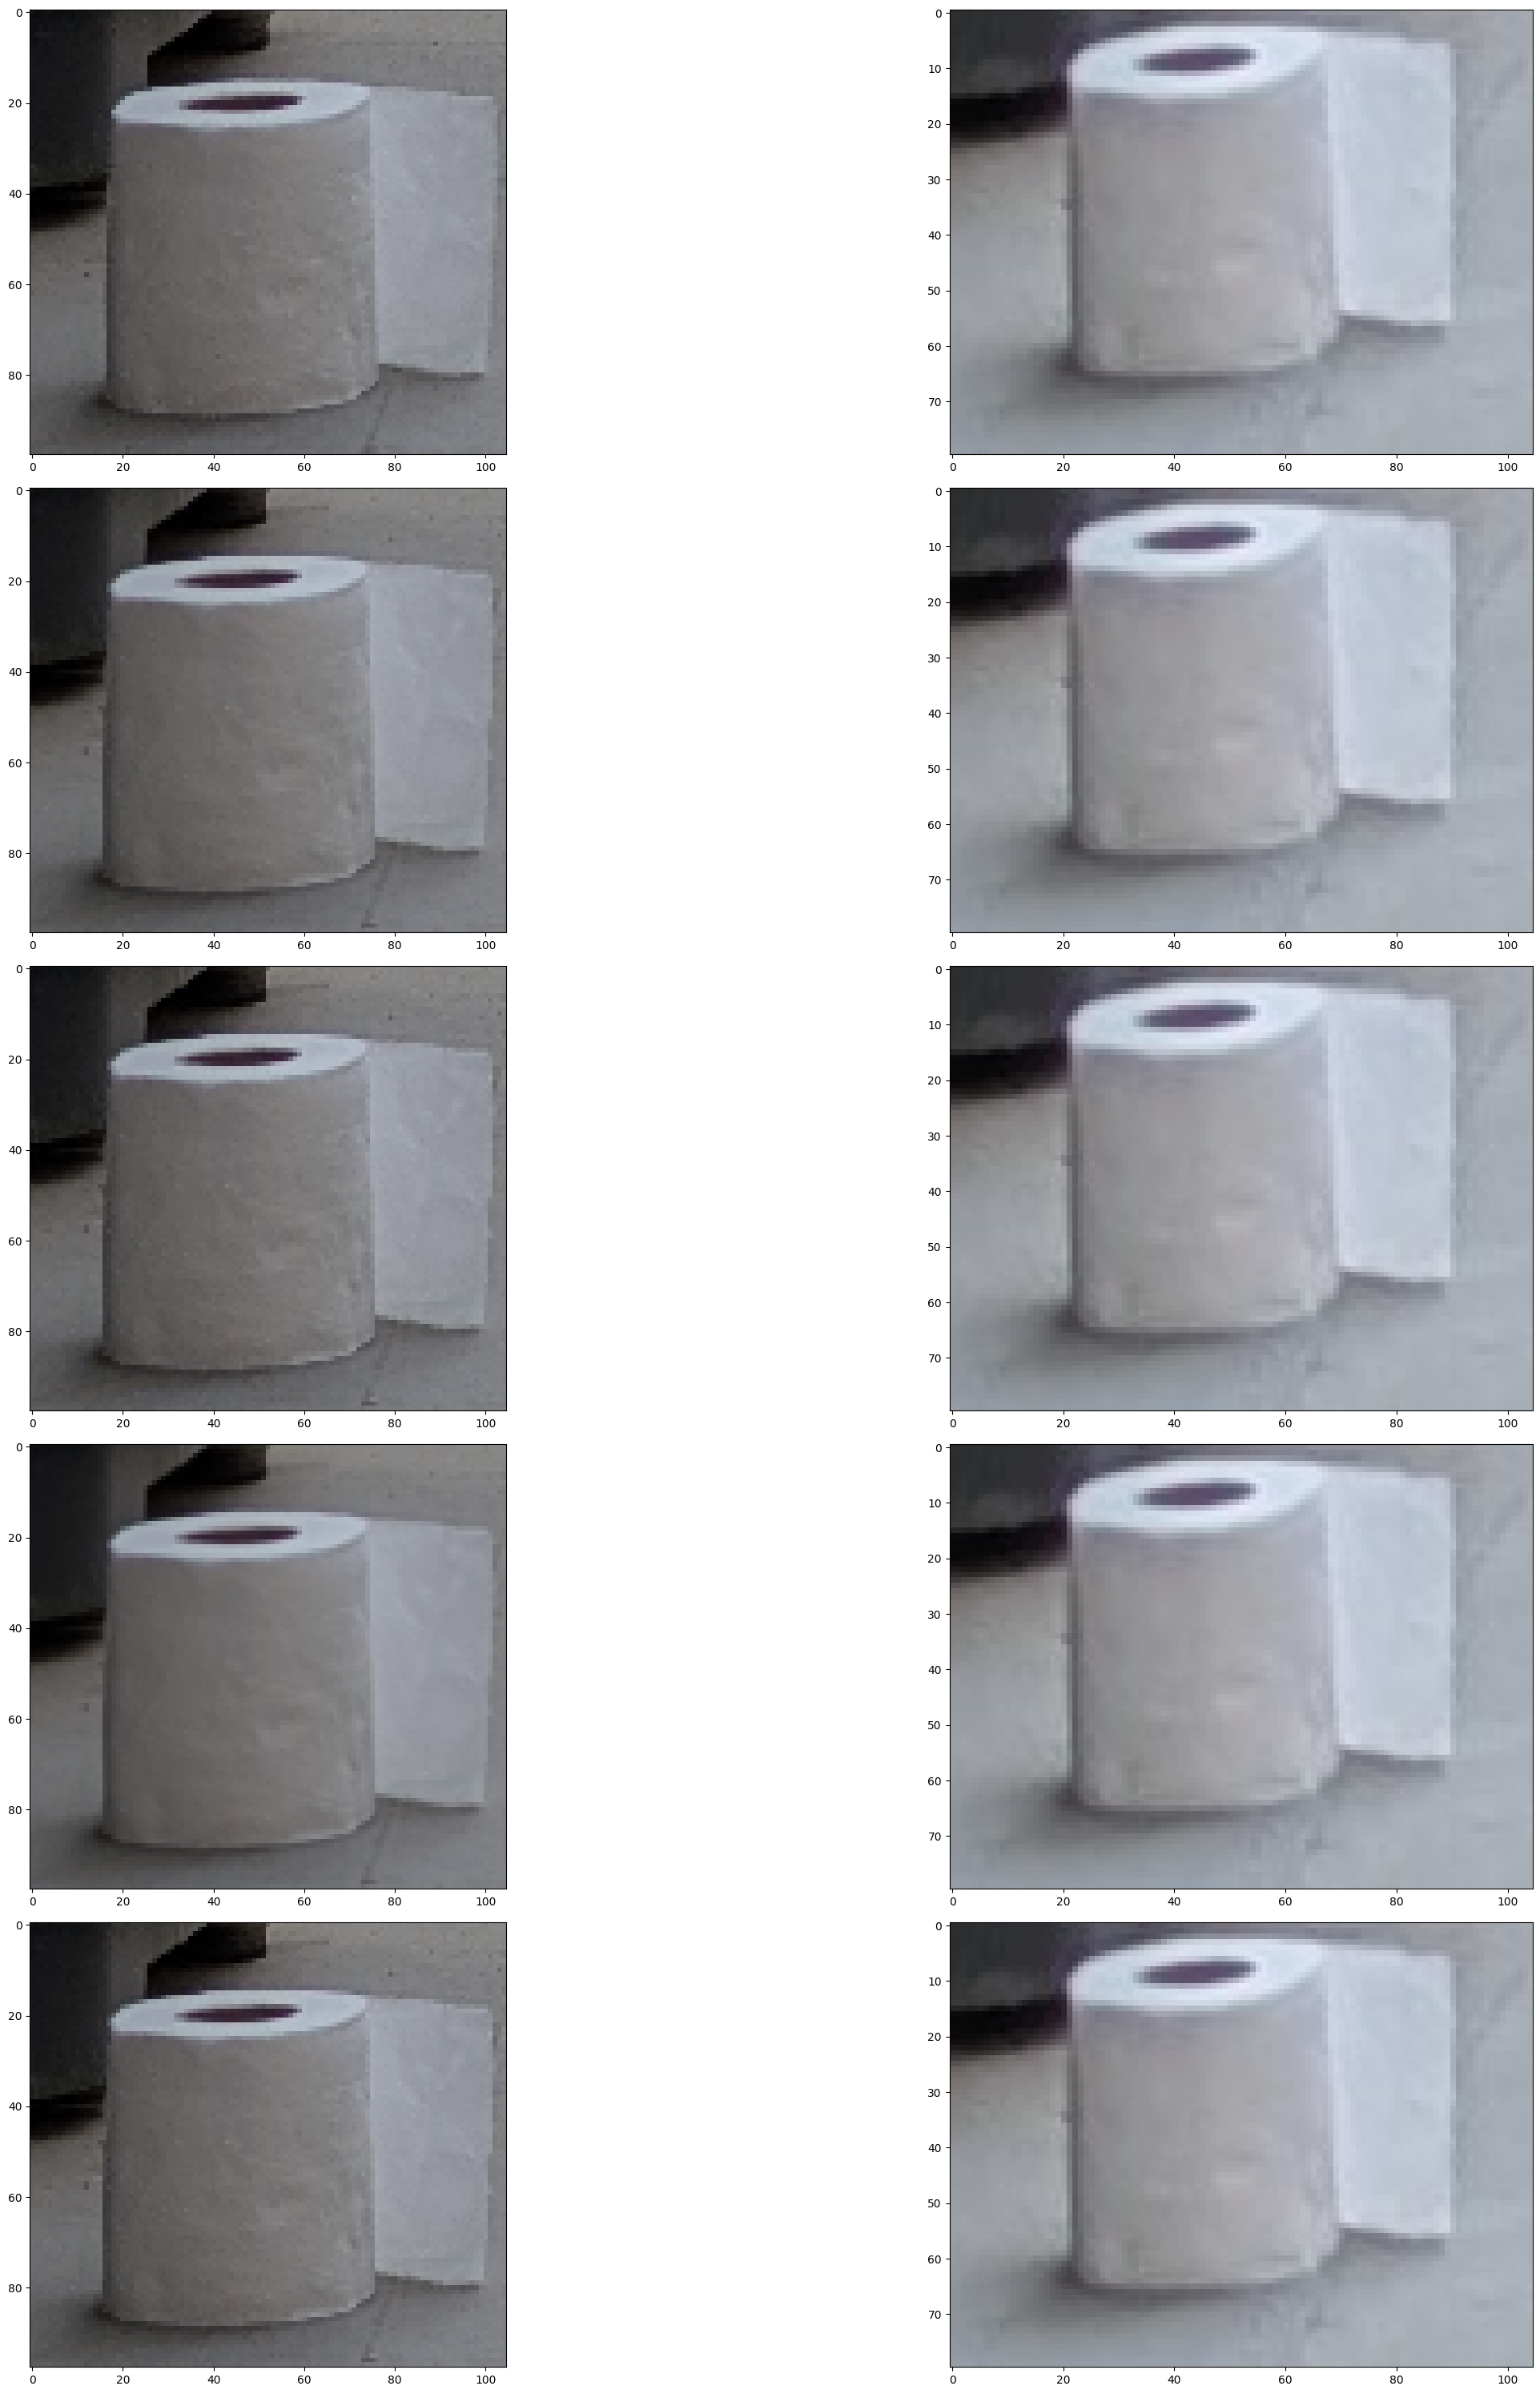

In [106]:
ORDER = [
    "NEAREST",
    "LINEAR",
    "LANCOZ",
    "AREA",
    "CUBIC",
]

rszs = [
    resized_w12_nearest,
    resized_w12_linear,
    resized_w12_lancoz,
    resized_w12_area,
    resized_w12_cubic,
]

crops = list(zip(rszs, itertools.repeat(w2_closeup)))
show_rx2(flt(crops), figsize=(30, 30))

the image on the right looks "blurrier" than the others right now. I is difficult to know what that means. I will examine the edges.

In [108]:
def _app_tpl(f):
    def applier(tpl):
        return tuple(f(t) for t in tpl)

    return applier


def _get_edge_crop(rsz_and_orig):
    rsz, orig = rsz_and_orig
    return rsz[10:40, 10:40], orig[:30, 15:45]


figsize (50, 50)


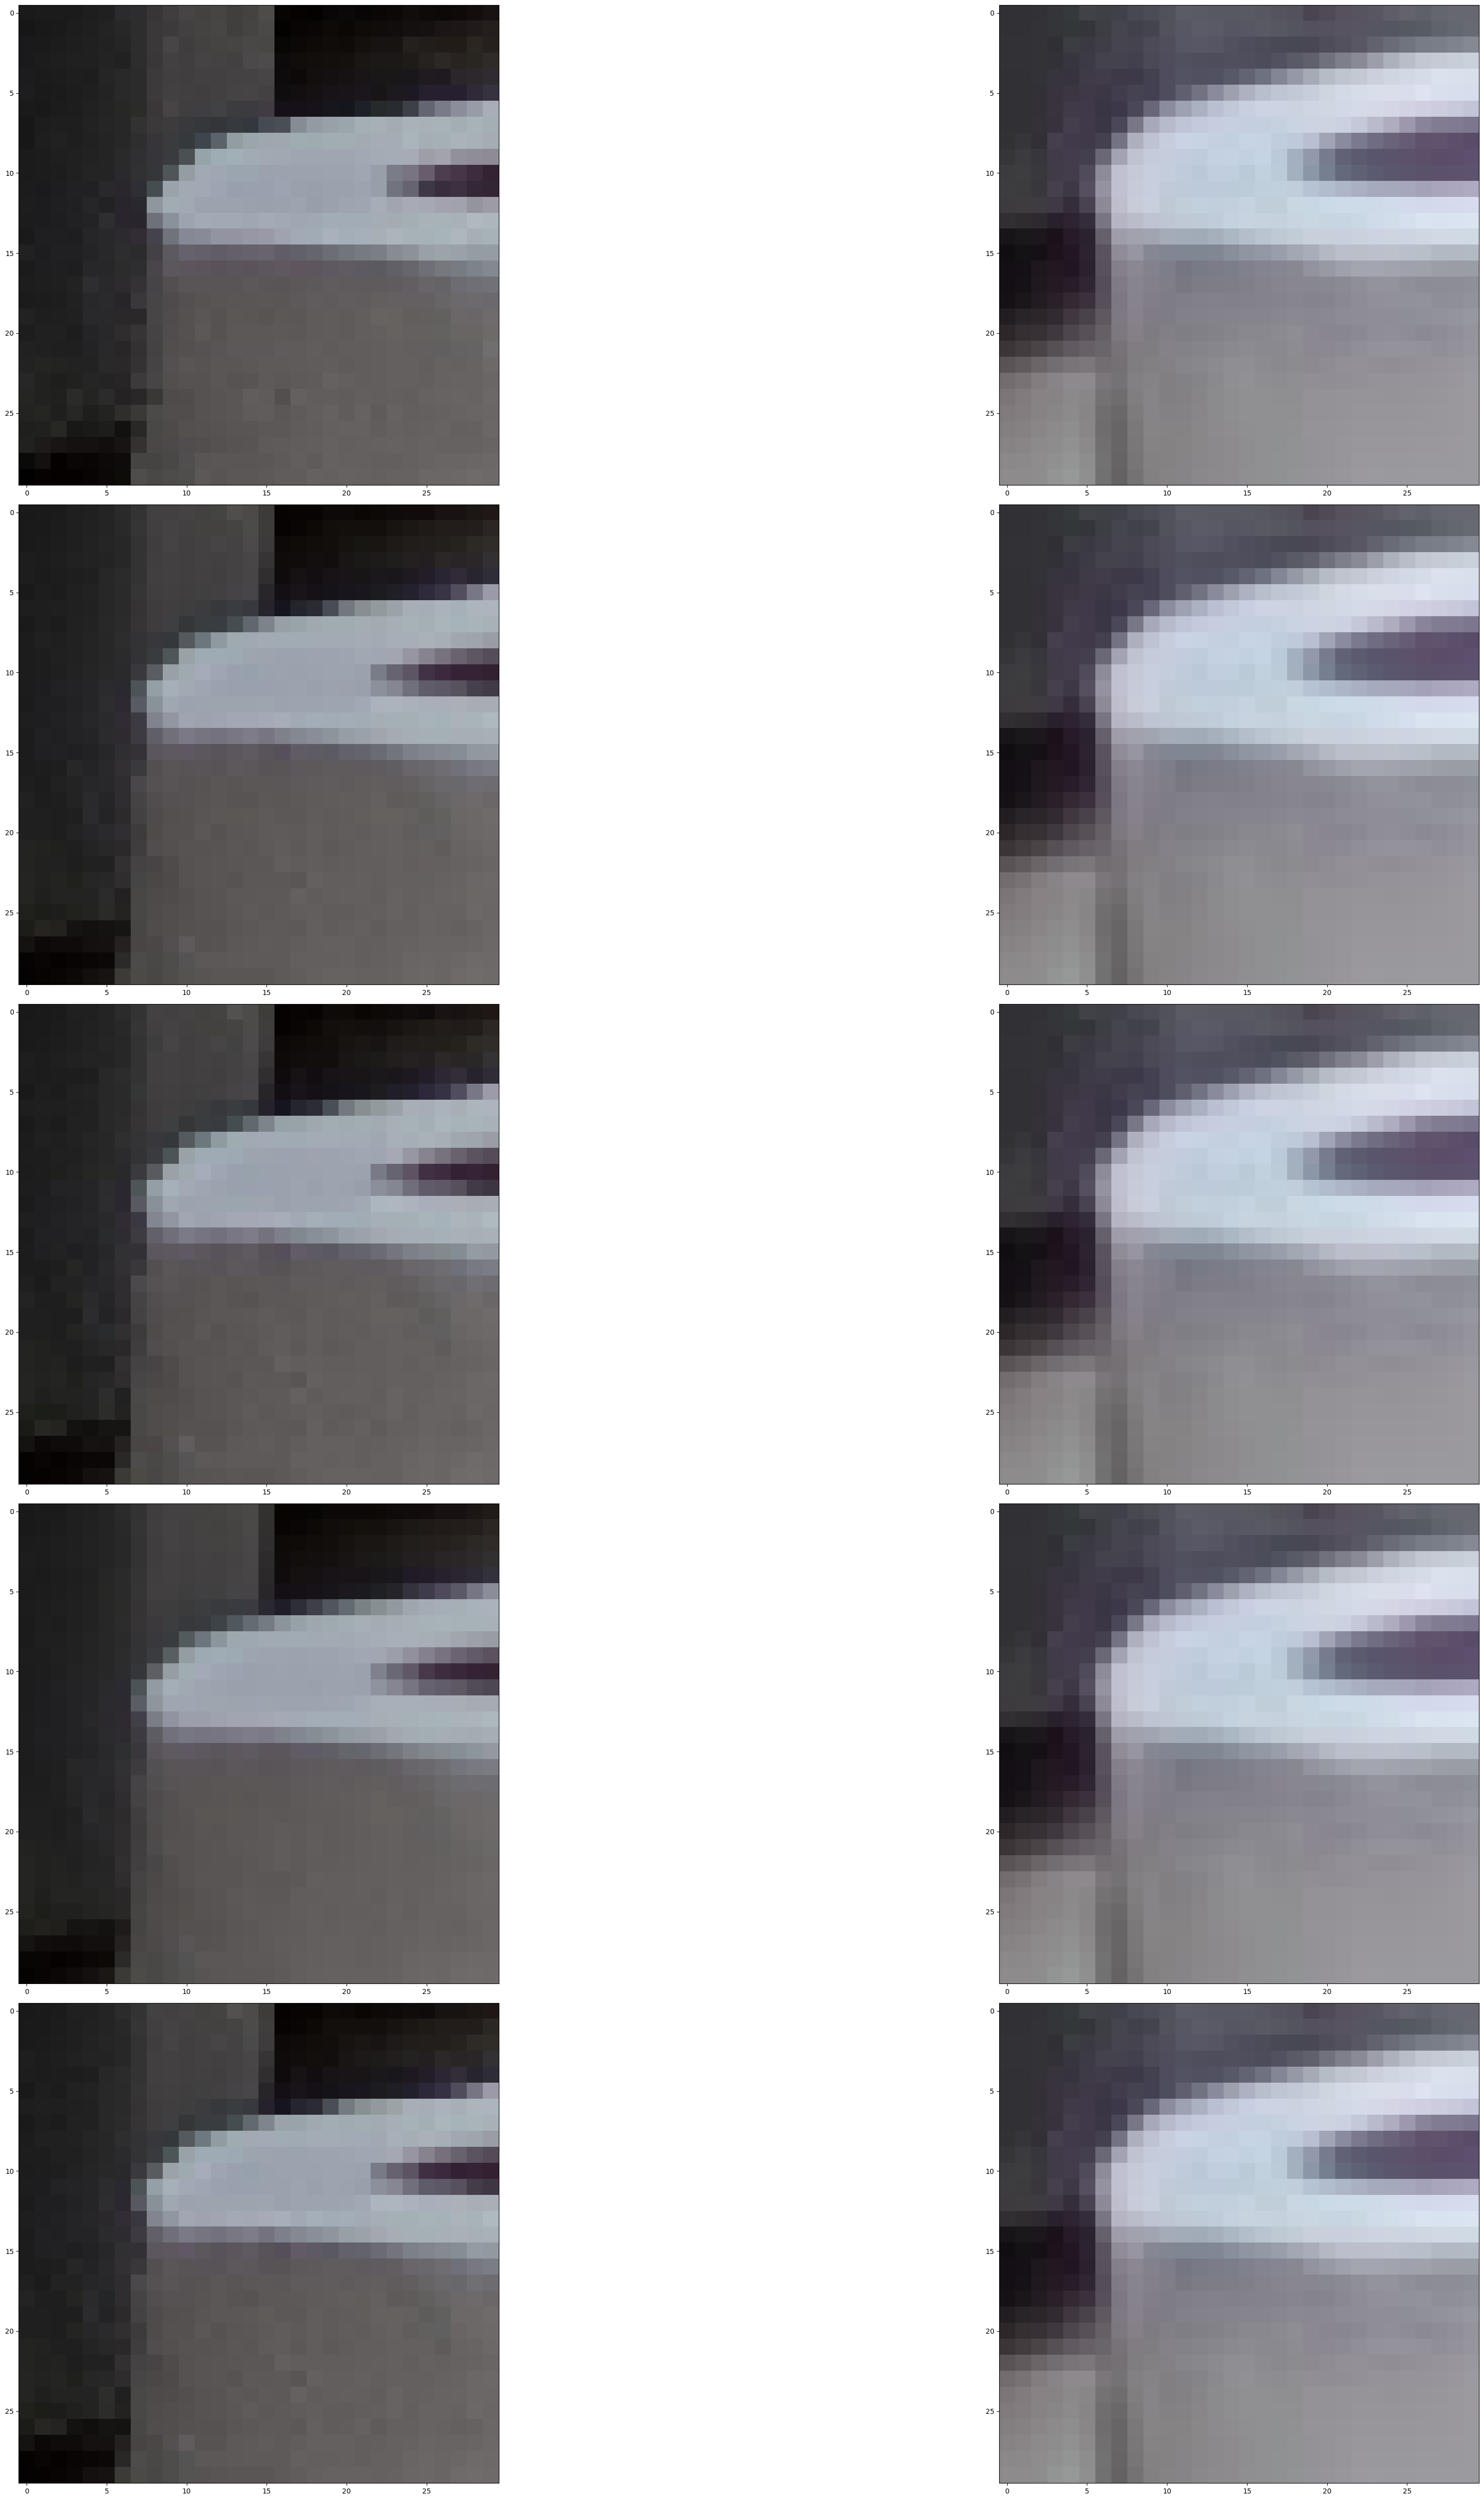

In [109]:
edges = [_get_edge_crop(c) for c in crops]
show_rx2(flt(edges))

A simple resize does look different at borders it seems. The borders of the second image are fuzzier. Let's look at borders I guess first. I see some changes.  
The number of pixels are definitely less. I need some way to measure the number of pixels in the border

In [110]:
w12_closeup.shape, resized_w12_area.shape

((300, 320, 3), (98, 105, 3))

figsize (10, 10)


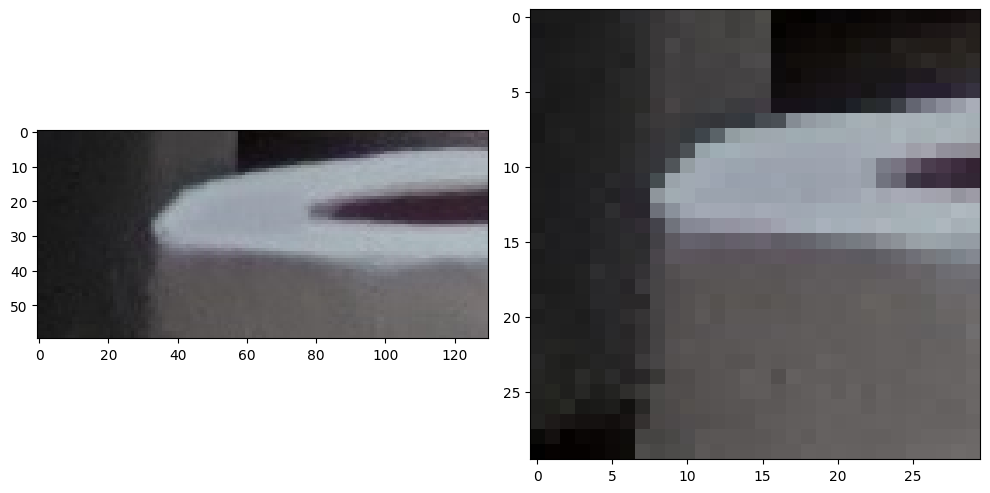

In [116]:
# between the original image and the flattened image, height wise, not a lot has changed in the dimension capture maybe. its half
# width wise it seems huge,
l = w12_closeup[40:100, 20:150]
r = edges[0][0]
show_rx2([l, r])

The above is a comparison between the original image and the resized image. The distance between edges has decreased due to interpolation.  

An edge is a place where light color changes. The light color does not change sharply though, there is a place where we have a mix of the two objects whose edges are in question. On the right of the edge, the right pixels are major, on the left, the left are major. If you look at the photo on the right above, we see a "line" of pixels which seem neither white nor brown/black [the background]. They seem a mix of those pixels. Light seems to mix around edges. How can I make this more "concrete"?  
What do I need to see near the area of transition?


Let's zoom in more on the first image to see a single edge with the surrounding closely


figsize (10, 10)


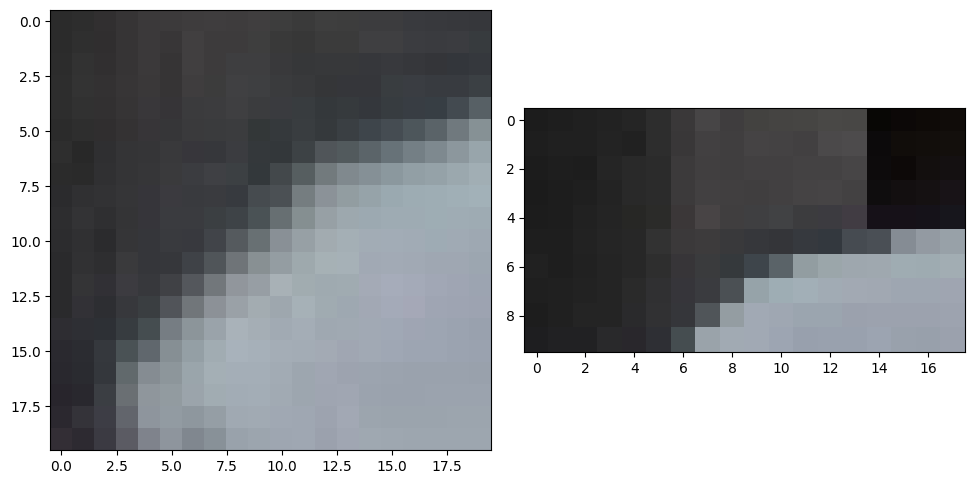

In [117]:
show_rx2([l[10:30, 30:50], r[2:12, 2:20]])

We see some pixels transitioning from white to black.  
The number of pixels it takes 5 pixels horizontally to make the change. Vertically, it is the same. Interesting. (This is mostly related to digital image formation and not to nature itself, not sure.).  
This is 1/2 for the image on the right.  
**The border mixing seems less in resized image compared to the actual distant image. Its less gradual, I need to increase its "gradualarity"**

This is simple and expected, since the density of pixels is so different.  
It seems to me that "how many pixels do I use to define the actual object" is quite important. A 50x50 tile can have objects which are small for that tile also, which the model can miss. In that case, the number of pixels to define that specific object are lesser. Currently, I'm taking a random crop around an object in TACO, and randomly resizing.  

I should set targets on the size of the actual object in pixels, target that. With this I get how much space I need to get of the surroundings of the object in the frame I want to resize.  


So for resizing, this is the first thing, make the object go down to x size, instead of the scenery going down to y size. (this applies to making stuff work in bigger frames also).   


Now, onto actual resizing logic

figsize (10, 10)


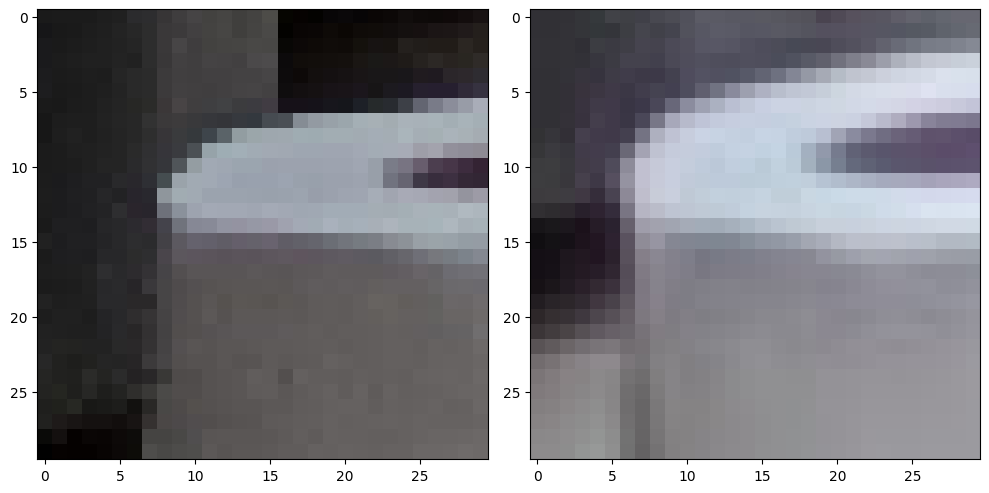

In [118]:
show_rx2(edges[0])

Before moving forward, I need to check which interpolation algorithm seems better to start with

['NEAREST', 'LINEAR', 'LANCOZ', 'AREA', 'CUBIC']
figsize (30, 30)


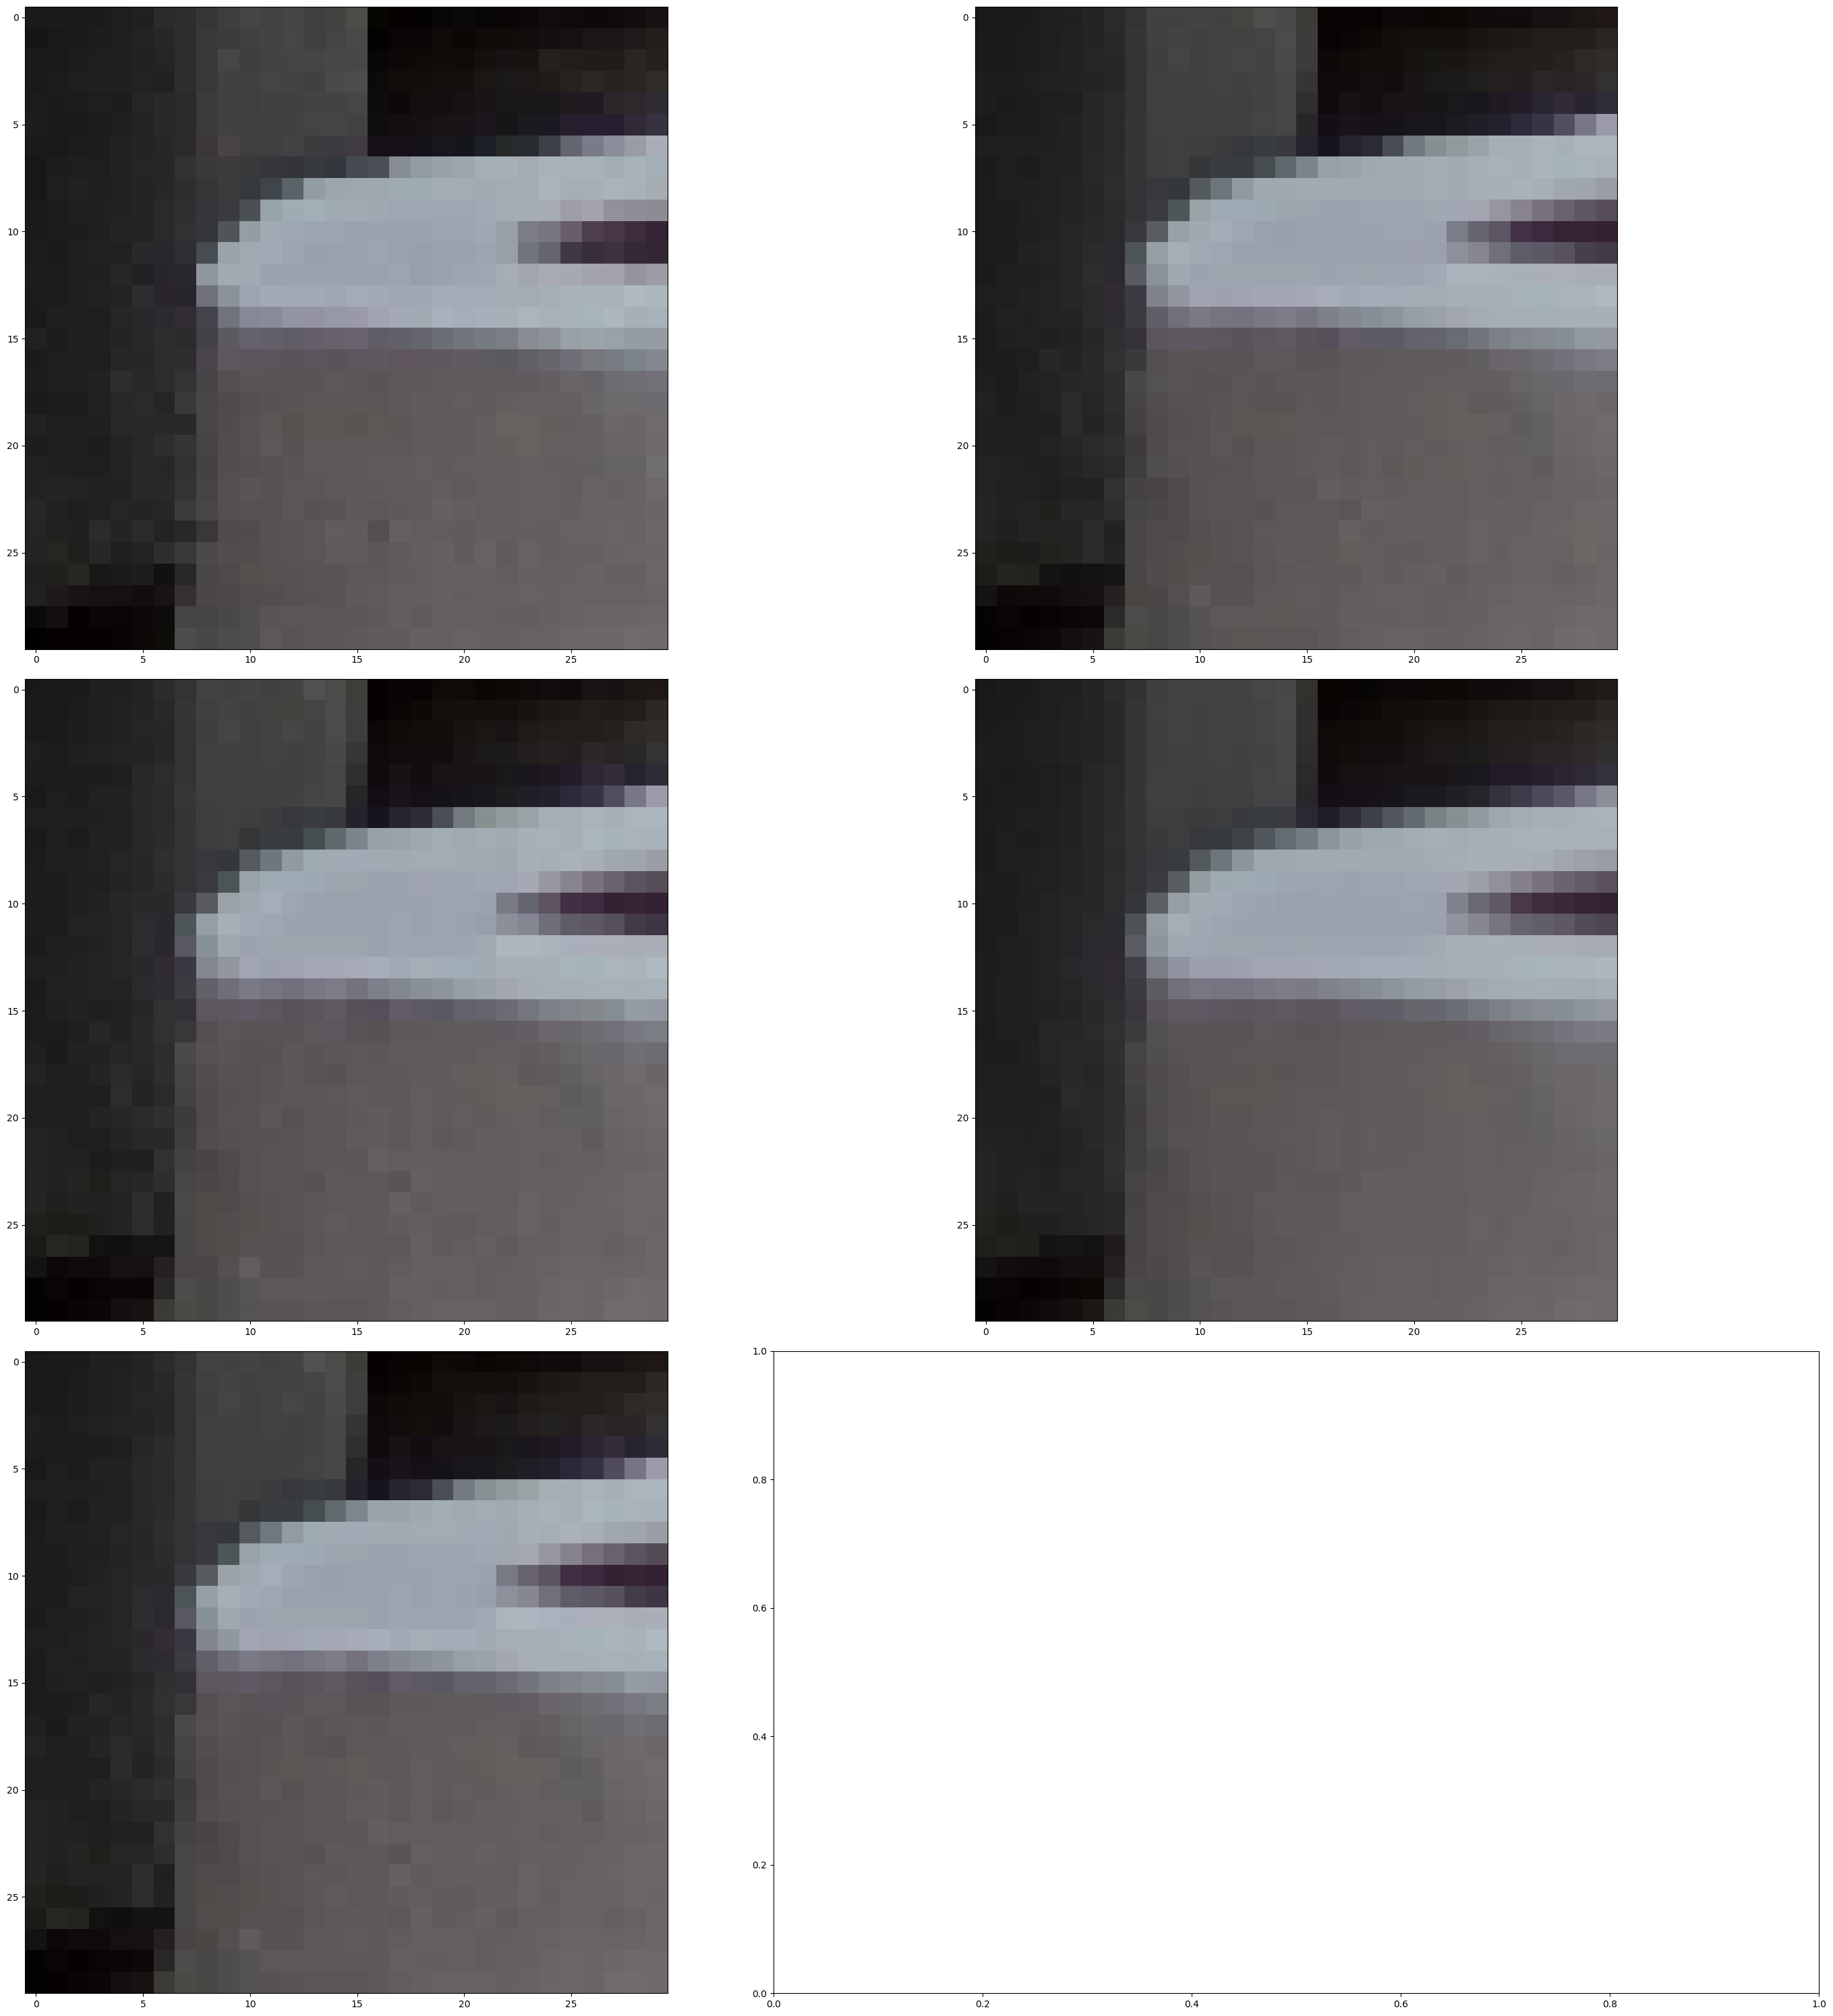

In [119]:
print(ORDER)
show_rx2([e[0] for e in edges])

They dont look extremely different to me right now lol. Let's move on with the first one (random)

In [120]:
rsz, orig = edges[0]
rsz, orig = rsz.copy(), orig.copy()

figsize (10, 10)


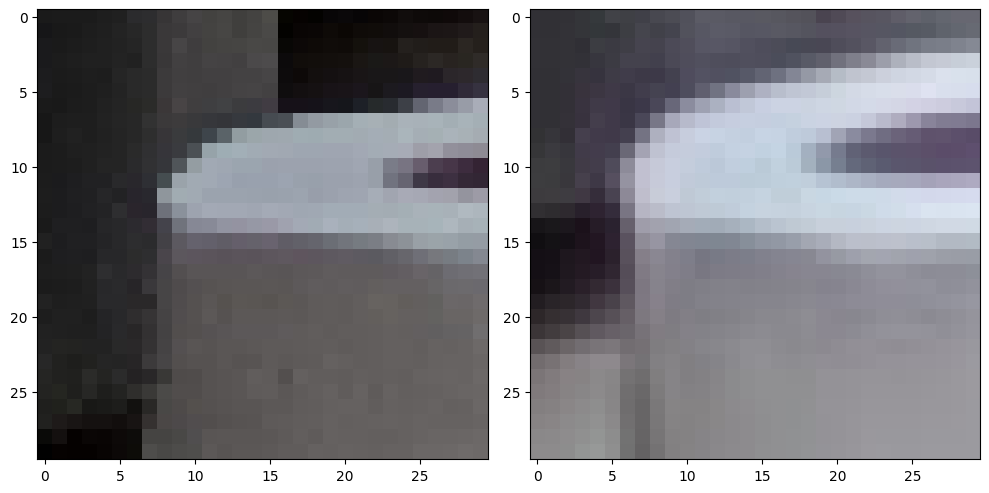

In [121]:
show_rx2([rsz, orig])

figsize (40, 40)


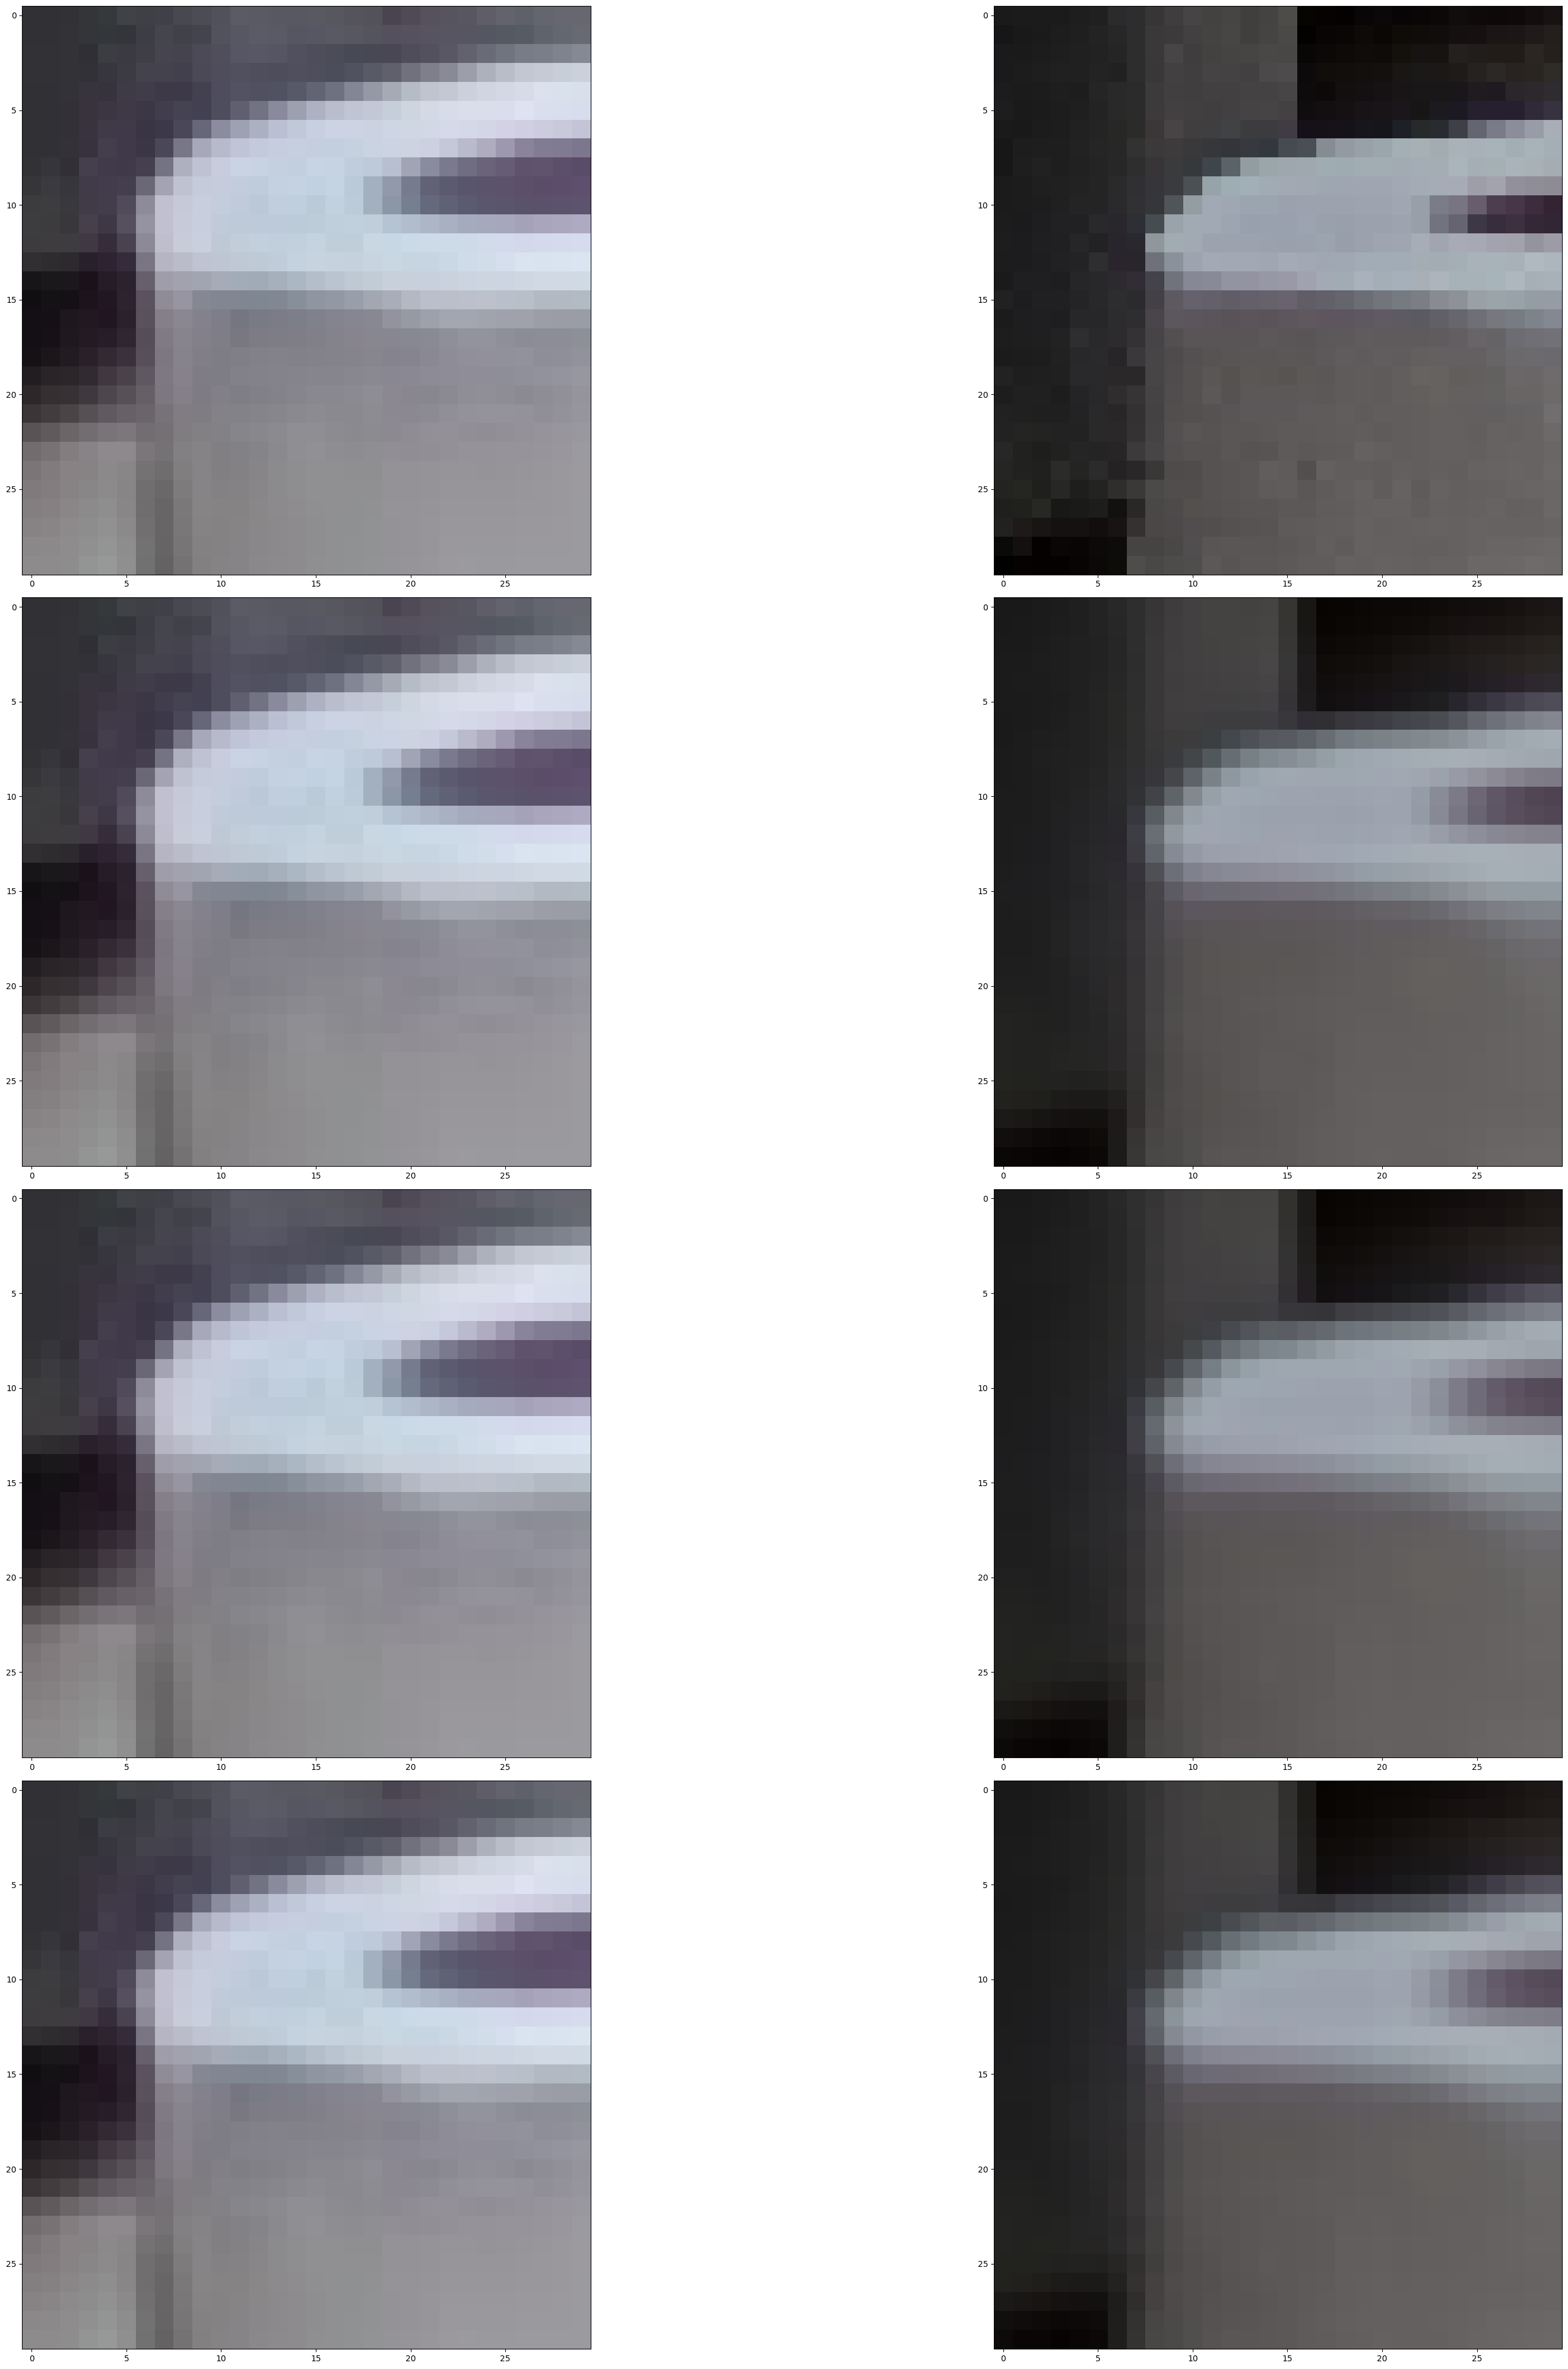

In [122]:
# (1,1) kernel is no go, doesnt do anything afaik

# try different sigma for 3x3 kernel
sig1 = cv2.GaussianBlur(rsz, (3, 3), sigmaX=1, sigmaY=1)
sig3 = cv2.GaussianBlur(rsz, (3, 3), sigmaX=3, sigmaY=3)
sig5 = cv2.GaussianBlur(rsz, (3, 3), sigmaX=5, sigmaY=5)

rsz_and_k3blur = list(
    zip(
        itertools.repeat(orig),
        [rsz, sig1, sig3, sig5],
    )
)


show_rx2(flt(rsz_and_k3blur), ncols=2)

I dont see a lot of differnce in different sigmas. Sigma=1 seems good enough lol. Lets look at full blurred stuff. It honestly does not look bad.  
For the next closest image, gaussian blur of k=(3,3) sigma=1 seems to work. AFTER resizing

figsize (10, 10)


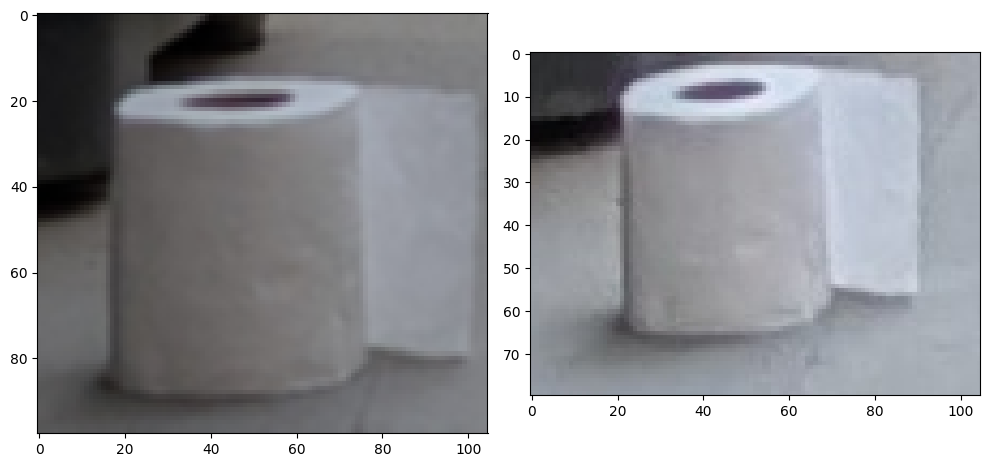

In [253]:
rsz, orig = crops[0]
rsz = cv2.GaussianBlur(rsz, (3, 3), 1, sigmaY=1)

show_rx2([rsz, orig])

Will blur before resizing now. And then resize

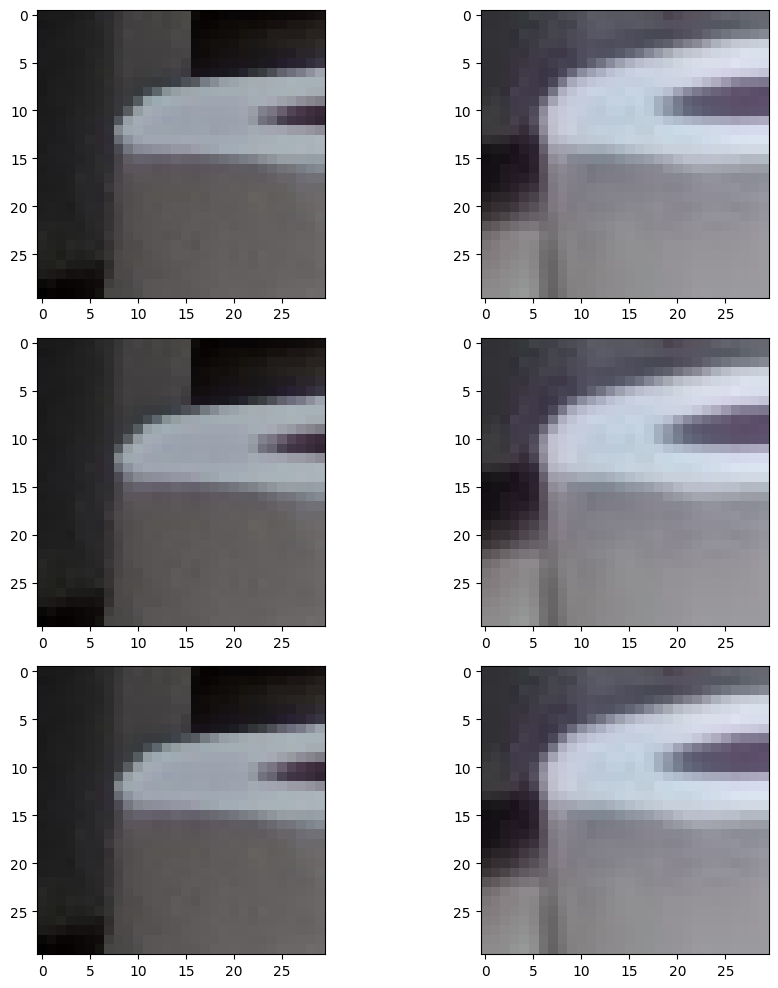

In [ ]:
blurs = [
    cv2.GaussianBlur(w12_closeup, (3, 3), 1, sigmaY=1),
    cv2.GaussianBlur(w12_closeup, (3, 3), 3, sigmaY=3),
    cv2.GaussianBlur(w12_closeup, (3, 3), 5, sigmaY=5),
]
blurs = [_resize(b, w2_closeup.shape[1], cv2.INTER_NEAREST) for b in blurs]
blurs = [_get_edge_crop(b) for b in zip(blurs, itertools.repeat(w2_closeup))]

# edges = _get_edge_crop((dest, w2_closeup))
show_rx2(flt(blurs), figsize=(10, 10))

Blurring before resizing is not working, fuck you chatgpt

# Wash: 2 -> 3

Ill try to convert the wash 2 to 3, we'll do 1->3 after this, useful to see how it looks

figsize (10, 10)


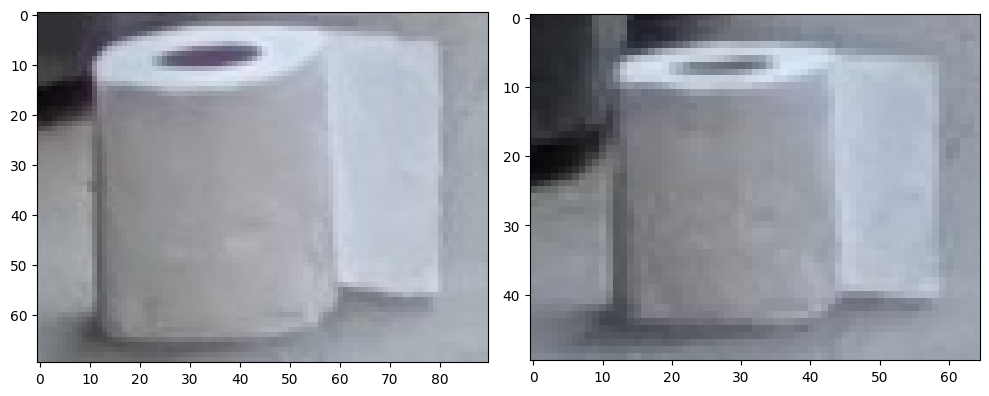

In [254]:
w2 = figs[1][2720:2790, 1160:1250]
w3 = figs[2][2390:2440, 1200:1265]
show_rx2([w2, w3])

figsize (10, 10)


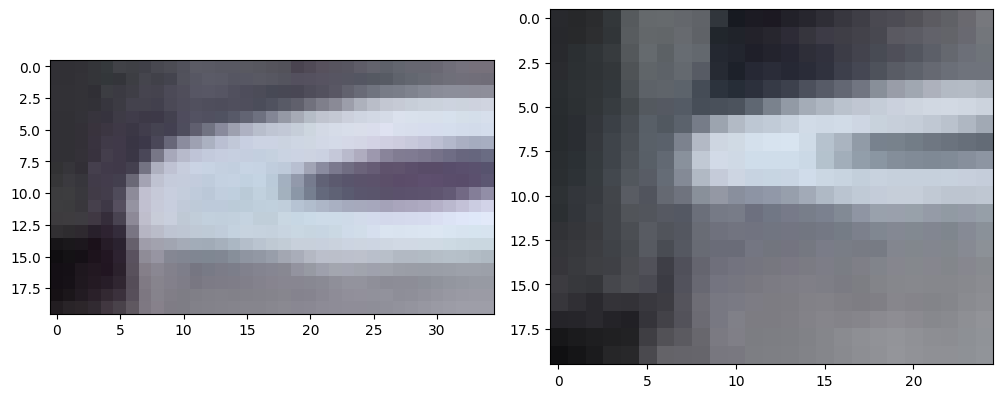

In [255]:
edges = [w2[:20, 5:40], w3[:20, 5:30]]
show_rx2(edges)

This seems like a separate beast, it looks like the roll has "mixed" with the background for some reason.  
The first thing we see is that brightness is a problem, the second photo does not as much light gathered as the first photo. This might be related to what I learned about image formation. Since we use lens, we can't gather light equally in every area, stuff not in focus is explicitly less illuminated.  

I will need to handle illumination too, separately.  

figsize (10, 10)


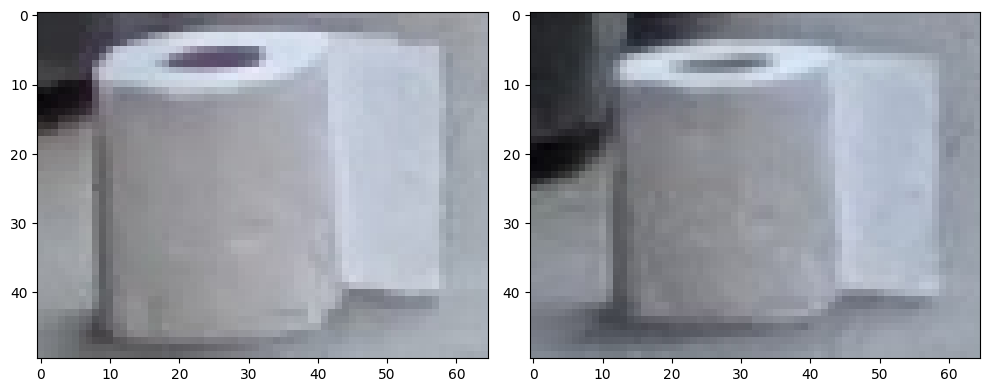

In [256]:
rsz = _resize(w2, w3.shape[1], cv2.INTER_NEAREST)
# this weird, why aspect ratio not good?
show_rx2([rsz, w3])

figsize (10, 10)


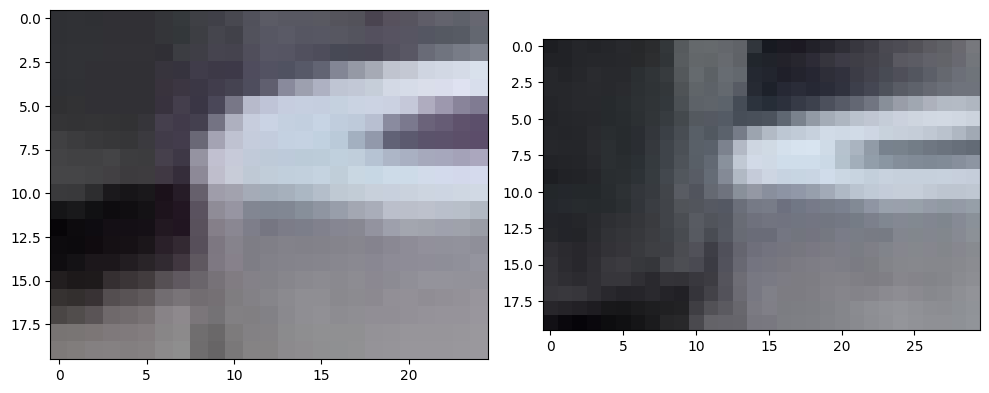

In [257]:
edges = [rsz[:20, :25], w3[:20, :30]]

show_rx2(edges)

At this distance, everything pretty much looks like a border lol. I should focus on the rectangle paper coming out on the right side, it might be easier

figsize (10, 10)


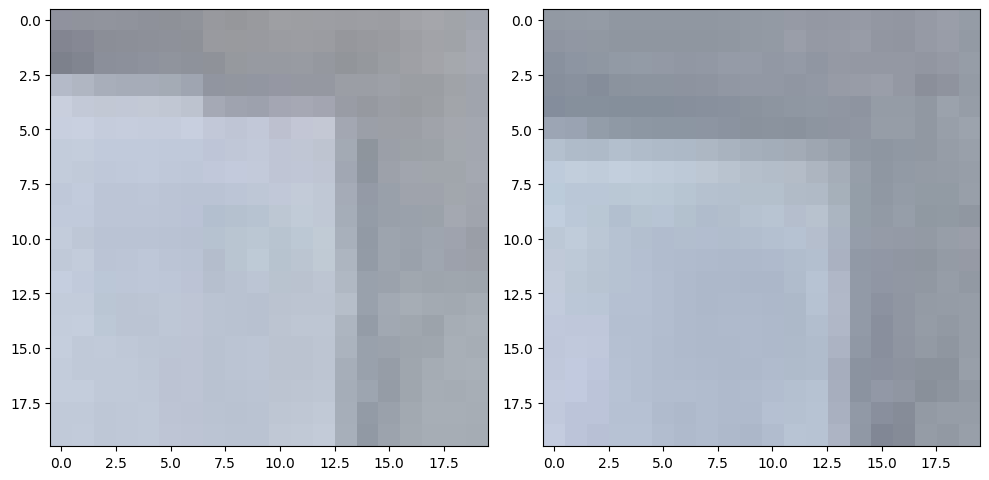

In [258]:
edges = [rsz[:20, 45:], w3[:20, 45:]]

show_rx2(edges)

The backgrounds are again blurring together extremely well here, t is hard for me to even notice the border here.   
Again, the first thing is the difference in brightness. This makes borders also harder to gauge, since the lesser bright the object is, the more is melds better with its background. Thus the border that I saw before, where you have two different backgrounds "mixing together" to form a true "border" does not look that easy to spot here.  

In the older case, there was a large area across which colors were mixing to form borders in the distant case, compared to the resized case. The resized case did not have this, and I needed to gaussian blur it to add those extra area for mixing.  


Honestly, even the bigger pictures dont look any differnent to me. Let's compare with a standard gaussian blur for the whole image first (our older result).  

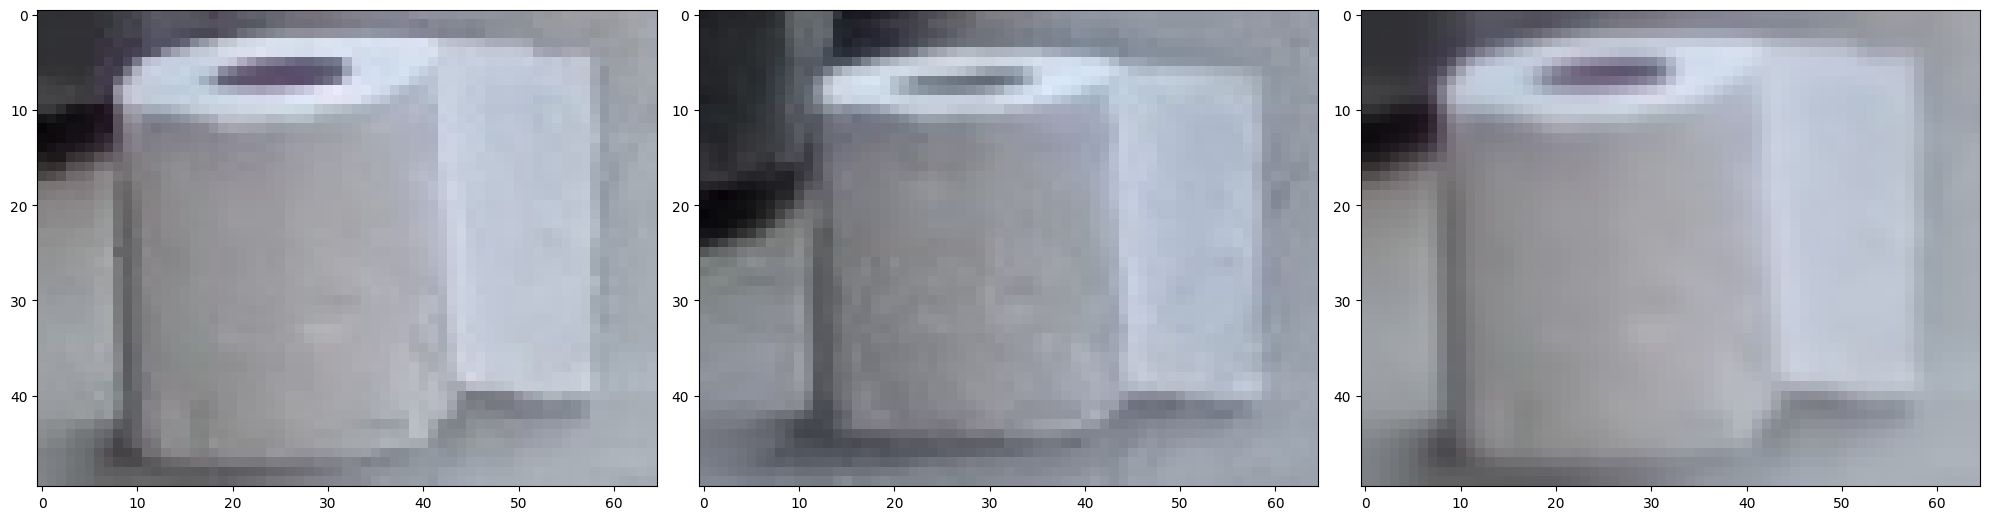

In [259]:
blur = cv2.GaussianBlur(rsz, (3, 3), sigmaX=1, sigmaY=1)
show_rx2([rsz, w3, blur], figsize=(20, 20), ncols=3)

For some reason, blurring is making things worse in this case. I feel the original resized image is a reasonable thing right now. Although, we could decrease the border pixels a bit more. The object seems to be bigger in w2 than in w3, lets fix that first

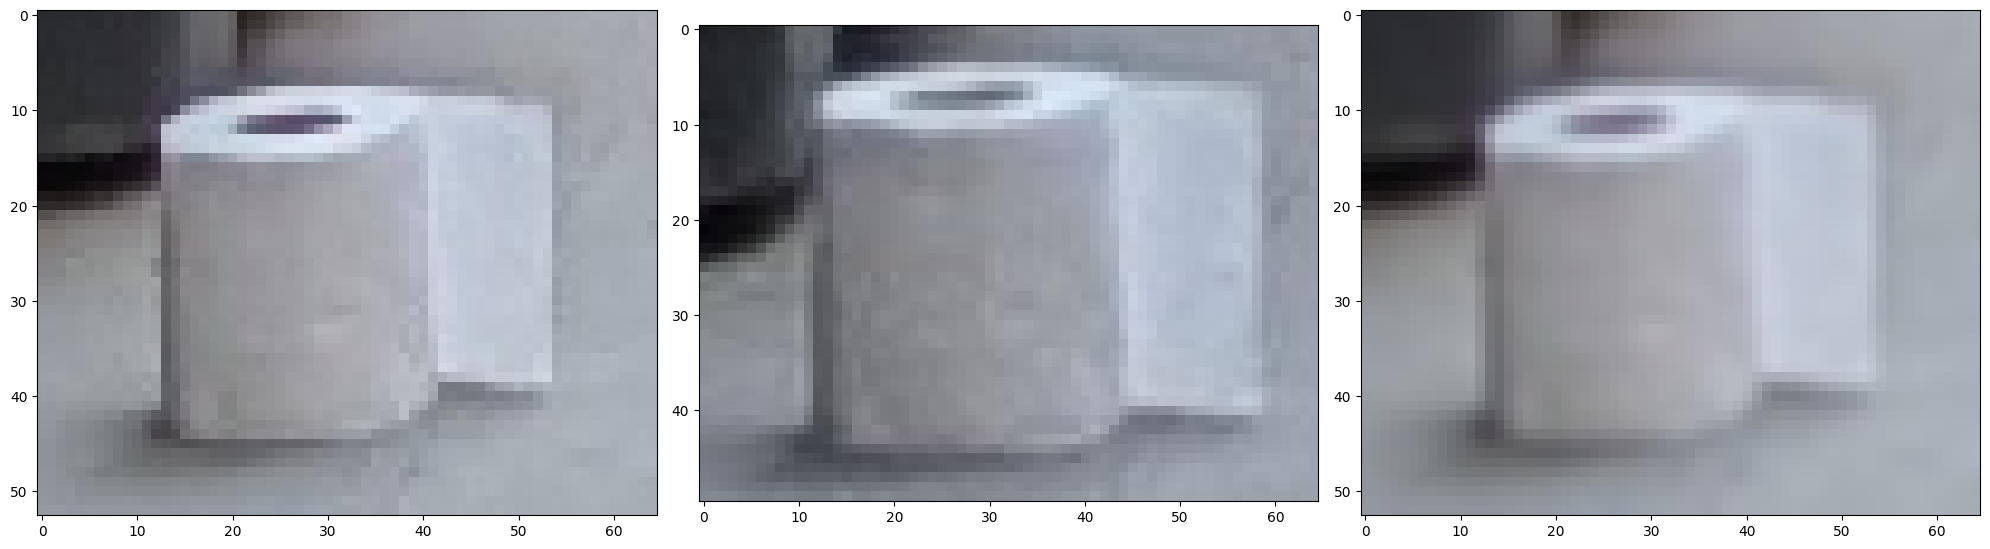

In [260]:
w2 = figs[1][2710:2800, 1150:1260]
w3 = figs[2][2390:2440, 1200:1265]
rsz = _resize(w2, w3.shape[1], cv2.INTER_NEAREST)
blur = cv2.GaussianBlur(rsz, (3, 3), 1, sigmaY=1)
show_rx2([rsz, w3, blur], (20, 20), ncols=3)

Blur is still making things worse, lets blur first and than resize

figsize (20, 20)


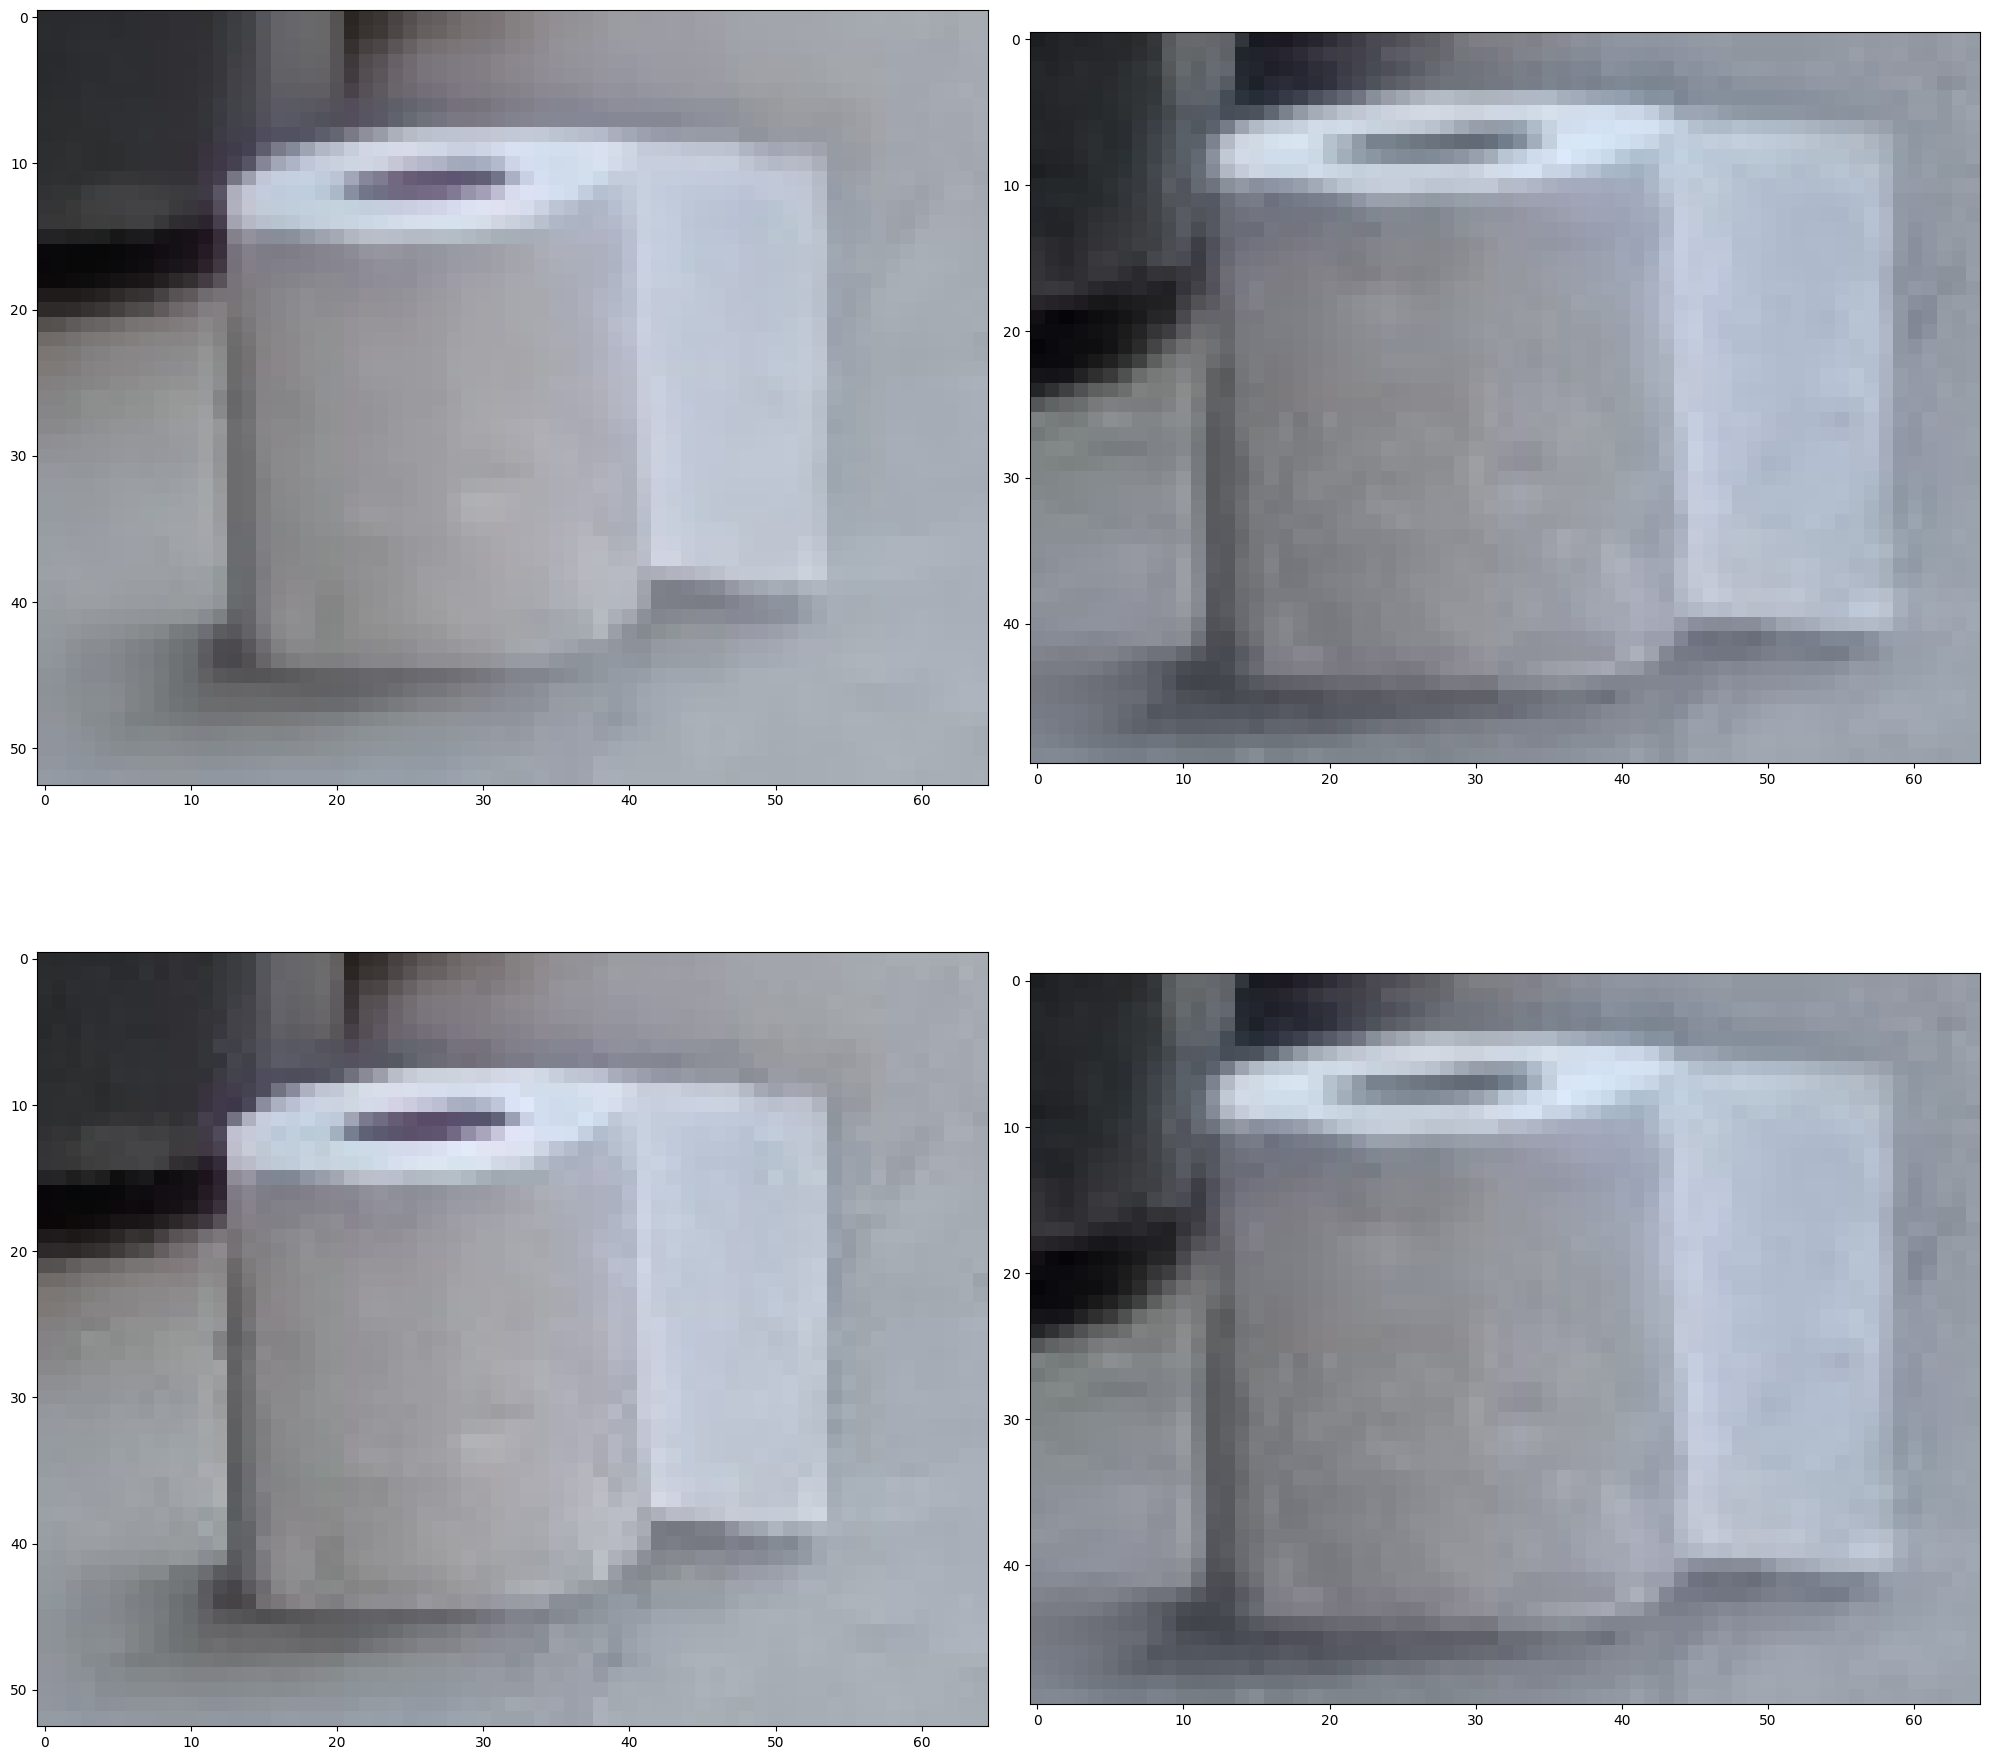

In [262]:
w2_direct_blur = cv2.GaussianBlur(w2, (3, 3), 1, sigmaY=1)
blur_before_rsz = _resize(w2_direct_blur, w3.shape[1], cv2.INTER_NEAREST)
show_rx2([blur_before_rsz, w3, rsz, w3])

I'm not convinced with this too. The blurring is not helping at all I think, only resize is fine. Let's go for brightness then

## Brightness

figsize (10, 10)


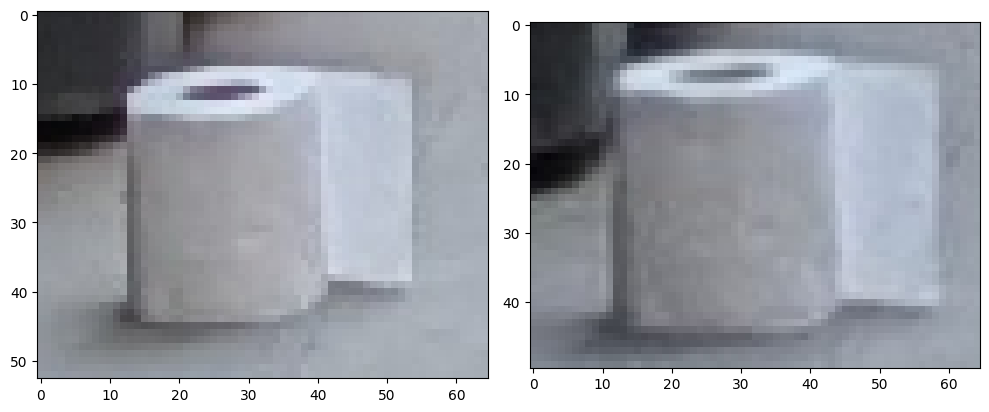

In [263]:
# ill use the LAB thing I've used before to first check on brightness
# original resized and w3
show_rx2([rsz, w3])

figsize (10, 10)


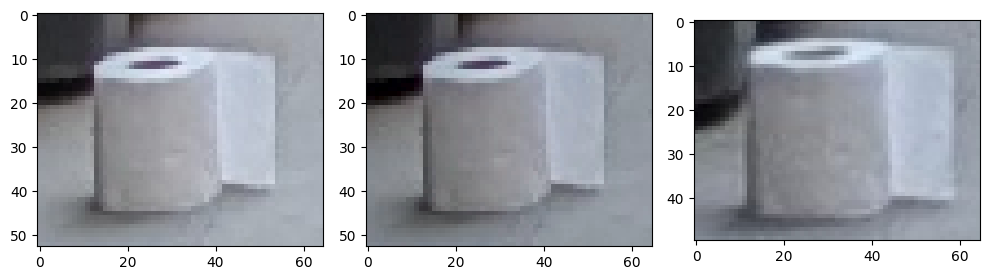

In [270]:
lab_rsz = cv2.cvtColor(rsz, cv2.COLOR_RGB2LAB)
lab_rsz[:,:,0] = np.clip(lab_rsz[:, :, 0].astype(np.int16) - 20, 0, 255).astype(np.uint8)
new_rsz = cv2.cvtColor(lab_rsz, cv2.COLOR_LAB2RGB)

show_rx2([rsz, new_rsz, w3], ncols=3)

The black is becoming too black? Less intensity of colors does not mean contrast I feel.  
I will need to experiment more

figsize (10, 10)


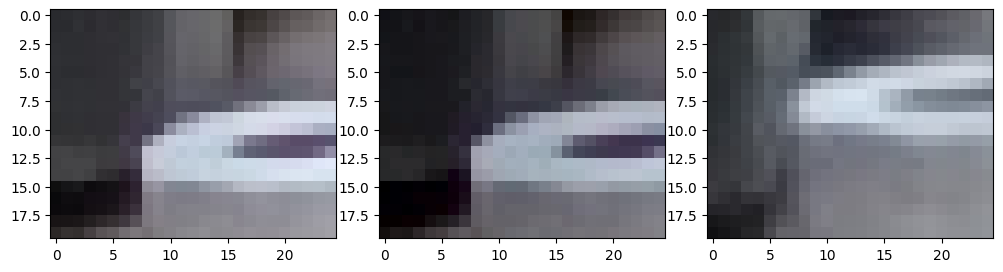

In [ ]:
# there is some residual blue in the converted image from LAB, that is quite wierd
show_rx2([rsz[:20, 5:30], new_rsz[:20, 5:30], w3[:20, 5:30]], ncols=3)

figsize (20, 20)


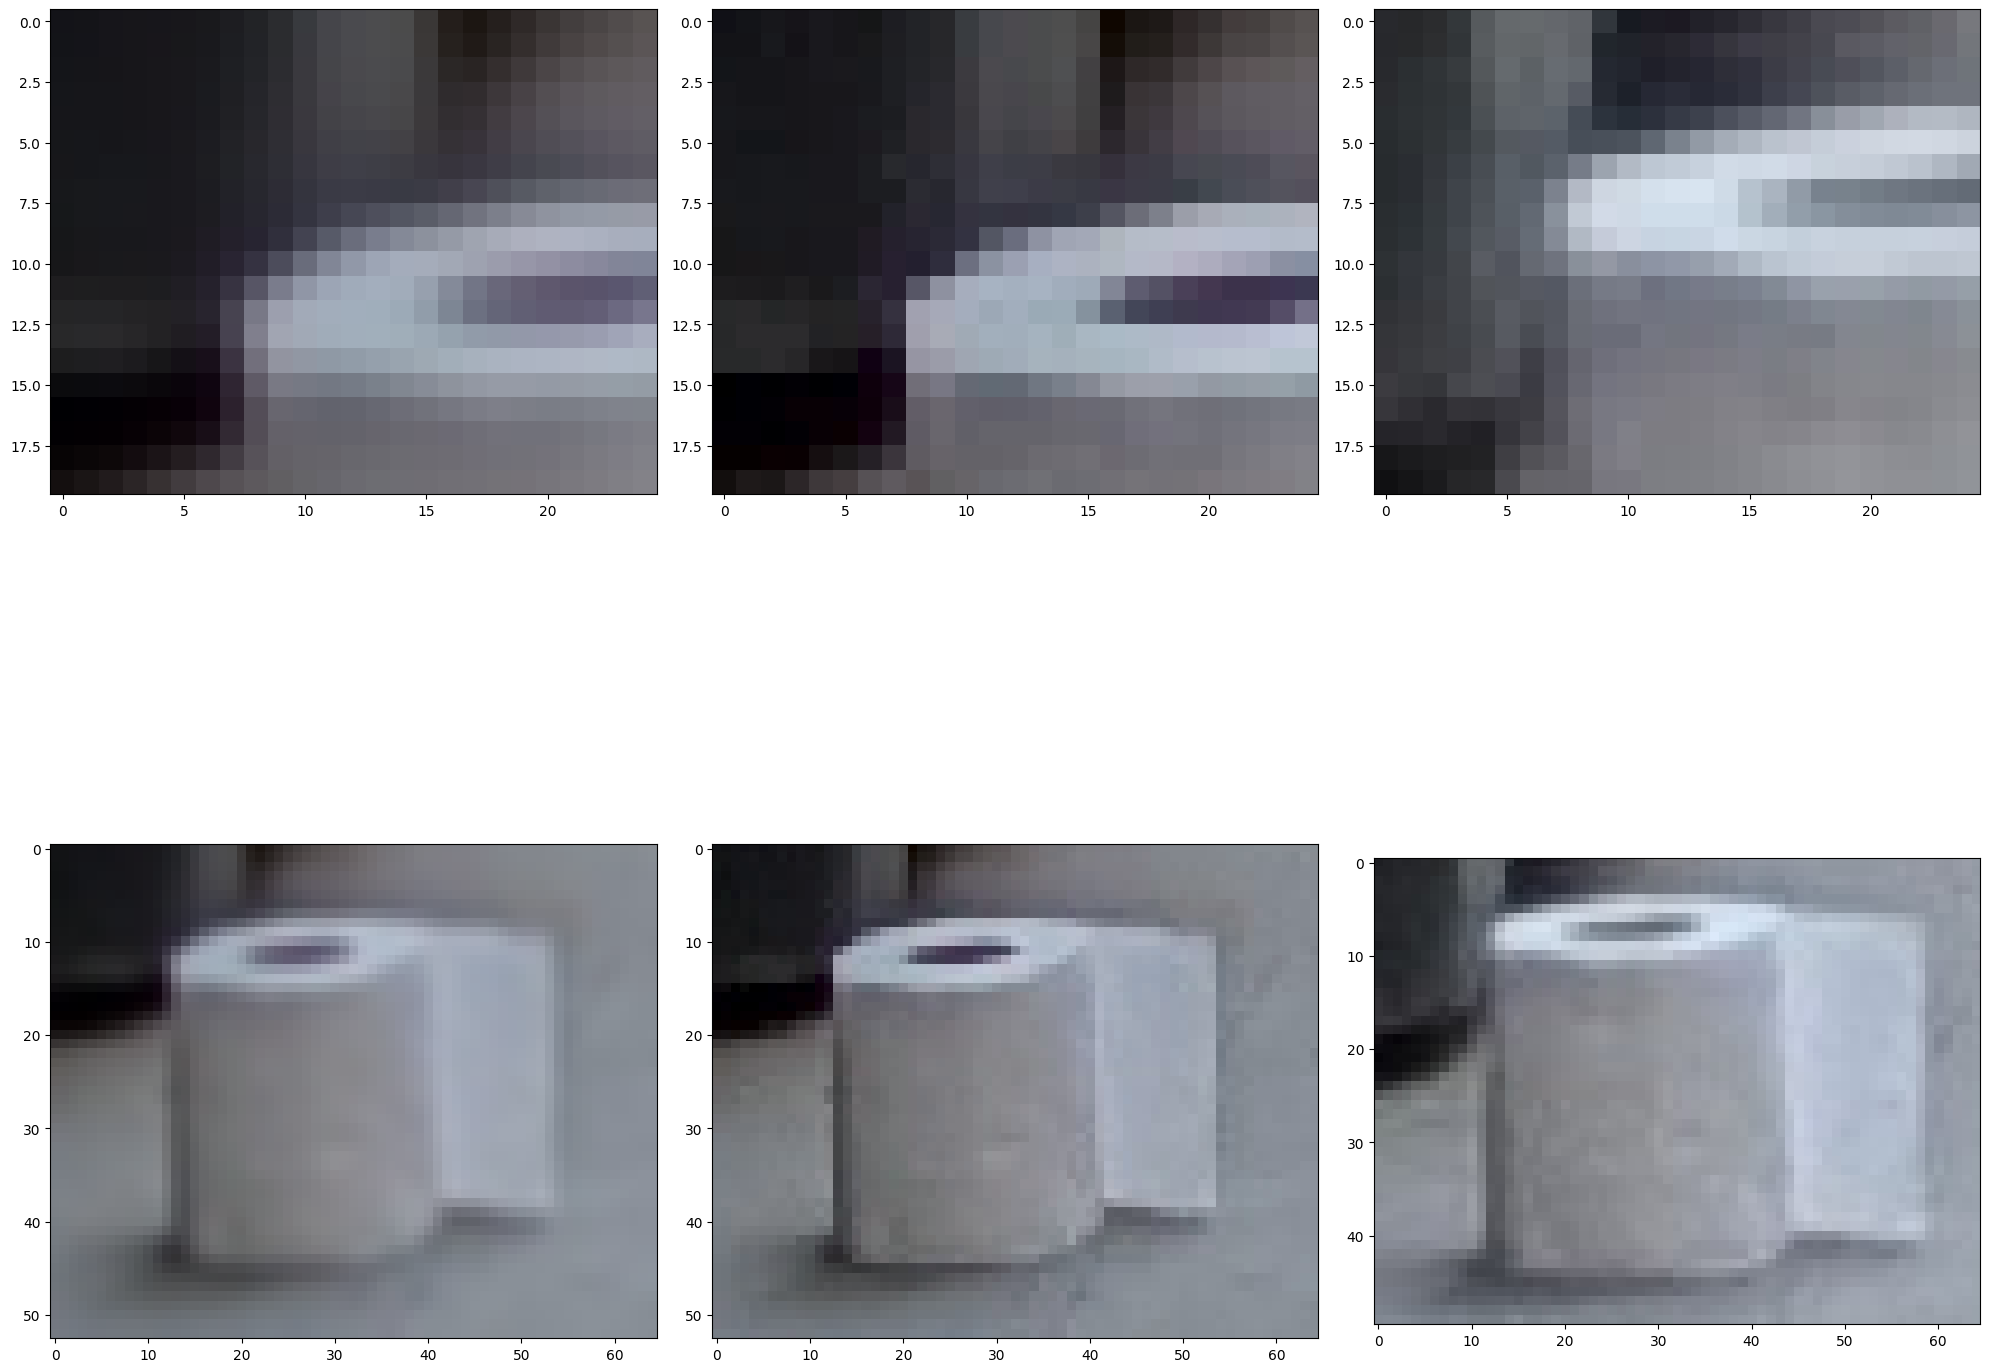

In [269]:
blurred = cv2.GaussianBlur(new_rsz, (3,3), 1, sigmaY=1)

show_rx2(flt([
    [blurred[:20, 5:30], new_rsz[:20, 5:30], w3[:20, 5:30]],
    [blurred, new_rsz, w3],
]), ncols=3)

Although blur at a close level looks pretty good I feel, but it just looks bad overall.   
There is too much fuzzing now, unreal looking fuzzying.  

In [ ]:
# Compute the histogram data with 3 bins
# hist, bin_edges = np.histogram(data, bins=3)

# print("Frequency counts (hist):", hist)
# print("Bin edges:", bin_edges)

figsize (10, 10)


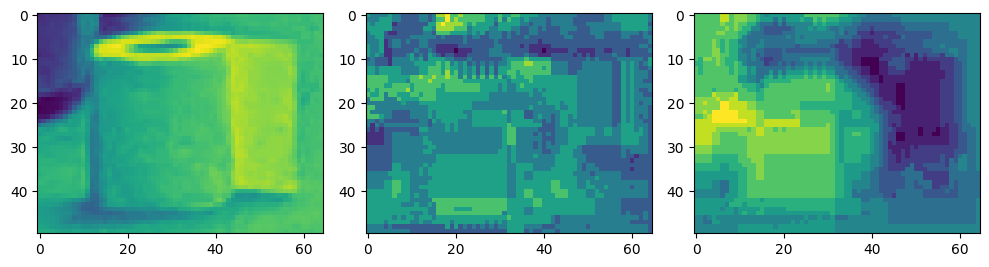

In [ ]:
show_rx2([lab_w3[:, :, 0], lab_w3[:, :, 1], lab_w3[:, :, 2]], ncols=3)

figsize (10, 10)


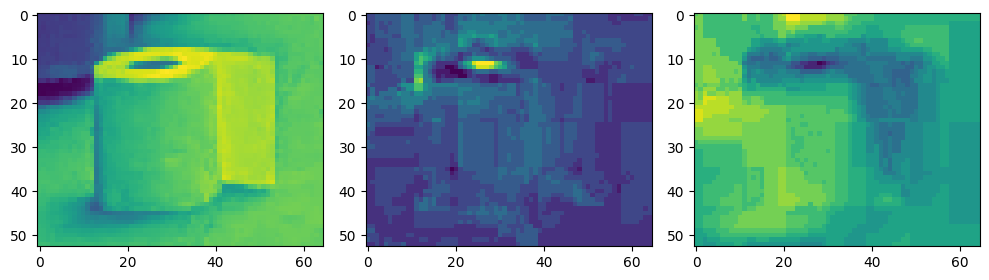

In [ ]:
show_rx2([lab_rsz[:, :, 0], lab_rsz[:, :, 1], lab_rsz[:, :, 2]], ncols=3)

figsize (10, 10)


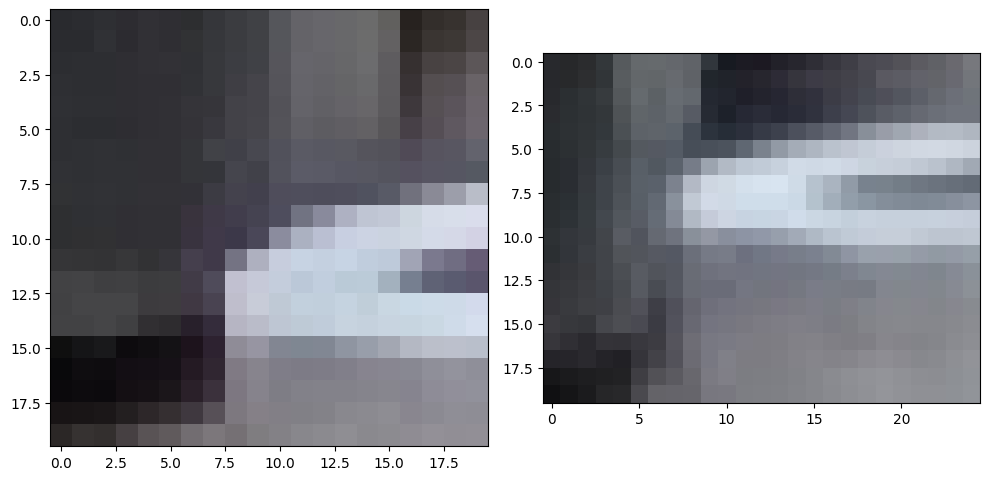

In [163]:
show_rx2([rsz[:20, 5:25], w3[:20, 5:30]])

figsize (10, 10)


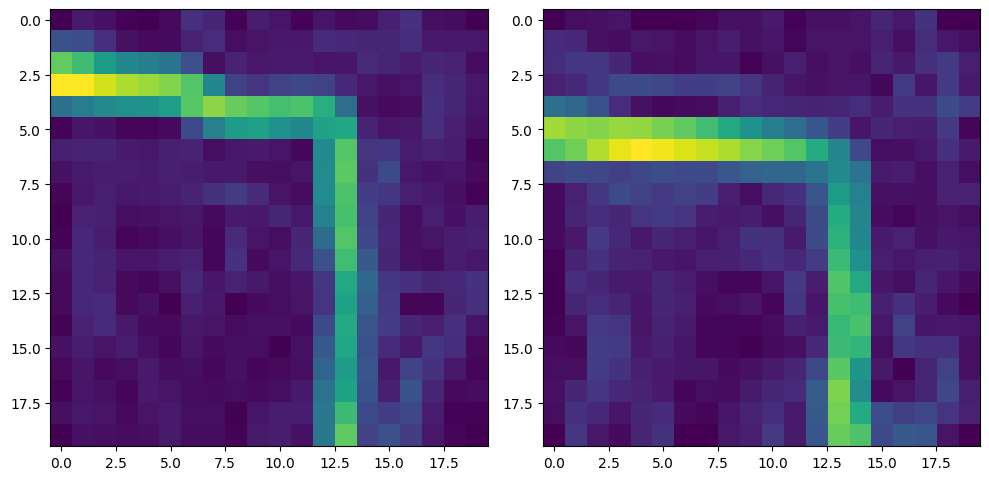

In [138]:
show_rx2([sobel_edge_detection(edges[0])[2], sobel_edge_detection(edges[1])[2]])